# Урок №6.Матричное дифференцирование

**Матричное дифференцирование** — это раздел математики, изучающий вычисление производных и градиентов функций, аргументами или значениями которых являются векторы и матрицы. Этот инструмент незаменим в машинном обучении (особенно в методе обратного распространения ошибки), оптимизации и эконометрике.

---

## 1. Основные типы производных

Размерность результата зависит от размерности входных и выходных данных. Ниже формулы представлены в рамках *denominator layout* (где размерность производной совпадает с размерностью знаменателя):

**Скаляр по вектору (Градиент):** Если $f: \mathbb{R}^n \to \mathbb{R}$, то производная — это вектор частных производных:

$$\nabla_x f(x) = \frac{\partial f}{\partial x} = \begin{pmatrix} \frac{\partial f}{\partial x_1} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{pmatrix}$$

**Вектор по вектору (Матрица Якоби):** Если $f: \mathbb{R}^n \to \mathbb{R}^m$, то результатом является матрица размером $m \times n$:

$$J = \frac{\partial f}{\partial x} = \begin{pmatrix} \frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\ \vdots & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n} \end{pmatrix}$$

**Скаляр по матрице:** Если $f: \mathbb{R}^{m \times n} \to \mathbb{R}$, то производная — это матрица того же размера $m \times n$:

$$\frac{\partial f}{\partial X} = \begin{pmatrix} \frac{\partial f}{\partial X_{11}} & \cdots & \frac{\partial f}{\partial X_{1n}} \\ \vdots & \ddots & \vdots \\ \frac{\partial f}{\partial X_{m1}} & \cdots & \frac{\partial f}{\partial X_{mn}} \end{pmatrix}$$

---

## 2. Метод дифференциалов (Универсальный подход)

Прямое вычисление частных производных по элементам часто приводит к громоздким выкладкам. Самый эффективный способ находить матричные производные — **метод дифференциалов**.

Для скалярной функции от матрицы $f(X)$ связь дифференциала и градиента выражается через след матрицы (Trace):

$$df(X) = \text{Tr}\left( \left(\frac{\partial f}{\partial X}\right)^T dX \right)$$

### Основные свойства дифференциалов:

При поиске дифференциалов действуют стандартные линейные правила, но **строго сохраняется порядок умножения матриц** (так как умножение некоммутативно):

- $d(A) = 0$ (для константной матрицы $A$)
- $d(\alpha X) = \alpha \, dX$
- $d(X \pm Y) = dX \pm dY$
- $d(XY) = (dX)Y + X(dY)$ *(Правило Лейбница)*
- $d(X^T) = (dX)^T$
- $d(\text{Tr}(X)) = \text{Tr}(dX)$
- $d(X^{-1}) = -X^{-1} (dX) X^{-1}$

---

## 3. Таблица часто используемых формул

В предположении, что $x$ — вектор, $X$, $A$ — матрицы:

| Выражение $f$ | Объект | Производная |
|:---|:---|:---|
| $a^T x$ | Скаляр по вектору | $\dfrac{\partial (a^T x)}{\partial x} = a$ |
| $x^T A x$ | Скаляр по вектору | $\dfrac{\partial (x^T A x)}{\partial x} = (A + A^T)x$ |
| $x^T A x$, $A = A^T$ | Скаляр по вектору | $\dfrac{\partial (x^T A x)}{\partial x} = 2Ax$ |
| $\|x\|^2$ | Скаляр по вектору | $\dfrac{\partial \|x\|^2}{\partial x} = 2x$ |
| $\|x\|$ | Скаляр по вектору | $\dfrac{\partial \|x\|}{\partial x} = \dfrac{x}{\|x\|}$ |
| $Ax$ | Вектор по вектору | $\dfrac{\partial (Ax)}{\partial x} = A$ |
| $a^T W b$ | Скаляр по матрице | $\dfrac{\partial (a^T W b)}{\partial W} = a b^T$ |
| $\|Wx - y\|^2$ | Скаляр по матрице | $\dfrac{\partial \|Wx - y\|^2}{\partial W} = 2(Wx - y)x^T$ |
| $\text{tr}(W^T A)$ | Скаляр по матрице | $\dfrac{\partial \text{tr}(W^T A)}{\partial W} = A$ |
| $\text{tr}(W A W^T)$ | Скаляр по матрице | $\dfrac{\partial \text{tr}(W A W^T)}{\partial W} = W(A + A^T)$ |

## Подробный разбор 10 базовых формул матричного дифференцирования

Ниже представлен разбор каждой формулы из таблицы. Все производные рассматриваются в соглашении **denominator layout** (размерность производной совпадает с размерностью переменной, по которой идет дифференцирование).

---

### 1. Производная линейной формы: $f(x) = a^T x$
* **Объекты:** $a, x$ — векторы-столбцы размера $n \times 1$. Их скалярное произведение записывается как $a^T x$ (результат — скаляр).
* **Смысл:** Это многомерный аналог обычной линейной функции $f(x) = kx$, где роль коэффициента $k$ играет вектор $a$.
* **Логика:** При изменении вектора $x$ функция меняется пропорционально компонентам вектора $a$. Дифференциал равен $df = a^T dx$, откуда по канонической форме $(\nabla_x f)^T dx$ получаем, что градиент равен самому вектору $a$.

$$\dfrac{\partial (a^T x)}{\partial x} = a$$

---

### 2. Производная квадратичной формы: $f(x) = x^T A x$
* **Объекты:** $x$ — вектор размера $n \times 1$, $A$ — произвольная квадратная матрица размера $n \times n$. Результат операции — скаляр.
* **Смысл:** Это аналог одномерной параболы $f(x) = ax^2$. В многомерном пространстве эта функция описывает эллипсоиды или гиперболоиды. Она лежит в основе вычисления дисперсий и вторых приближений функций.
* **Логика:** Из-за некоммутативности матриц приращение идет с двух сторон: от левого $x^T$ и от правого $x$. Дифференциал равен $df = (dx)^T Ax + x^T A dx = x^T A^T dx + x^T A dx = x^T(A + A^T)dx$. Транспонируя выражение перед $dx$, получаем итоговую формулу.

$$\dfrac{\partial (x^T A x)}{\partial x} = (A + A^T)x$$

---

### 3. Частный случай квадратичной формы для симметричной матрицы ($A = A^T$)
* **Объекты:** Тот же скаляр, но на матрицу $A$ наложено ограничение симметрии (например, матрица ковариации или $A = X^T X$ в линейной регрессии).
* **Смысл:** Прямая аналогия с обычной производной параболы: $(ax^2)' = 2ax$.
* **Логика:** Так как $A = A^T$, скобка $(A + A^T)$ превращается в $(A + A) = 2A$. Формула становится максимально компактной.

$$\dfrac{\partial (x^T A x)}{\partial x} = 2Ax$$

---

### 4. Производная квадрата евклидовой нормы: $f(x) = \|x\|^2$
* **Объекты:** $x$ — вектор размера $n \times 1$. Квадрат его длины (нормы) равен $\|x\|^2 = x^T x$.
* **Смысл:** Это расстояние от начала координат до точки $x$ в квадрате. Базовая часть функции потерь MSE.
* **Логика:** Это частный случай формулы №3, где роль матрицы $A$ играет единичная матрица $I$ (так как $x^T I x = x^T x$). Подставляя $A = I$ в формулу $2Ax$, получаем $2Ix = 2x$.

$$\dfrac{\partial \|x\|^2}{\partial x} = 2x$$

---

### 5. Производная евклидовой нормы (длины вектора): $f(x) = \|x\|$
* **Объекты:** $x$ — вектор размера $n \times 1$, функция возвращает его физическую длину (скаляр).
* **Смысл:** Описывает, как меняется расстояние до точки при её смещении. Используется в L1-регуляризации (Lasso) и геометрических задачах.
* **Логика:** Применяется правило производной сложной функции (корень из квадрата нормы): $(\sqrt{\|x\|^2})' = \frac{1}{2\sqrt{\|x\|^2}} \cdot (\|x\|^2)' = \frac{1}{2\|x\|} \cdot 2x = \frac{x}{\|x\|}$. Градиент — это единичный вектор, указывающий направление от центра координат к точке $x$.

$$\dfrac{\partial \|x\|}{\partial x} = \dfrac{x}{\|x\|}$$

---

### 6. Производная линейного преобразования: $f(x) = Ax$ (Вектор по вектору)
* **Объекты:** $x$ — вектор размера $n \times 1$, $A$ — матрица-константа размера $m \times n$. Результат — новый вектор размера $m \times 1$.
* **Смысл:** Это вычисление **матрицы Якоби** для линейного слоя нейросети (без функции активации) или любого линейного отображения.
* **Логика:** Дифференциал равен $df = A dx$. В соглашении *denominator layout* матрица Якоби должна иметь размерность $n \times m$. Относительно дифференциала $df = J^T dx$, мы получаем $J^T = A$, откуда сам Якобиан равен $J = A^T$. Однако, при итоговой записи градиентного шага в ML эту матрицу принято сразу транспонировать обратно для сохранения цепочки умножения сложной функции (Chain Rule).

$$\dfrac{\partial (Ax)}{\partial x} = A$$

---

### 7. Билинейная форма по матрице весов: $f(W) = a^T W b$
* **Объекты:** $a$ — вектор $m \times 1$, $b$ — вектор $n \times 1$, а дифференцирование идет по **матрице** $W$ размера $m \times n$. Результат функции — скаляр.
* **Смысл:** Показывает, как взвешенная сумма связей между двумя векторами реагирует на изменение каждого отдельного веса. Применяется в механизмах внимания (Attention) и бинарных квадратичных формах.
* **Логика:** Используем свойство следа матрицы для скаляров: $a^T W b = \text{Tr}(a^T W b) = \text{Tr}(b a^T W)$. Дифференциал равен $df = \text{Tr}(b a^T dW) = \text{Tr}((a b^T)^T dW)$. По канонической форме $\text{Tr}((\frac{\partial f}{\partial W})^T dW)$ получаем ответ $a b^T$. Размеренность градиента ($m \times n$) строго совпадает с размерностью $W$.

$$\dfrac{\partial (a^T W b)}{\partial W} = a b^T$$

---

### 8. Градиент квадрата ошибки матричного слоя: $f(W) = \|Wx - y\|^2$
* **Объекты:** $W$ — матрица весов $m \times n$, $x$ — вектор признаков $n \times 1$, $y$ — вектор ответов $m \times 1$. Результат — скаляр ошибки.
* **Смысл:** Это 핵심-формула (главная формула) для обучения полносвязных слоев (Linear/Dense Layers) в нейросетях. Она отвечает на вопрос: «Как нужно изменить каждый элемент матрицы весов $W$, чтобы уменьшить ошибку прогноза на объекте $x$?».
* **Логика:** Обозначим вектор ошибки как $e = Wx - y$. Тогда функция равна $e^T e$. Её дифференциал равен $2e^T de$. Так как $de = d(Wx - y) = dW \cdot x$, подставляем: $df = 2e^T dW x$. Используем циклический сдвиг под знаком следа: $2e^T dW x = 2 \text{Tr}(e^T dW x) = 2 \text{Tr}(x e^T dW) = \text{Tr}((2ex^T)^T dW)$. Отсюда считываем градиент.

$$\dfrac{\partial \|Wx - y\|^2}{\partial W} = 2(Wx - y)x^T$$

---

### 9. Производная следа произведения: $f(W) = \text{tr}(W^T A)$
* **Объекты:** $W$ и $A$ — матрицы одинакового размера $m \times n$. Функция возвращает след (сумму диагональных элементов) их произведения — скаляр.
* **Смысл:** Операция $\text{tr}(W^T A)$ в матричном анализе — это то же самое, что скалярное произведение для векторов. Она часто встречается при работе с Фробениусовой нормой матриц (аналог MSE для матричных выходов).
* **Логика:** Дифференциал равен $df = \text{Tr}(d(W^T) A) = \text{Tr}((dW)^T A) = \text{Tr}(A (dW)^T) = \text{Tr}(A^T dW)$. Сравнивая с каноническим видом $\text{Tr}((\frac{\partial f}{\partial W})^T dW)$, получаем, что $(\frac{\partial f}{\partial W})^T = A^T$, следовательно, сама производная равна $A$.

$$\dfrac{\partial \text{tr}(W^T A)}{\partial W} = A$$

---

### 10. Производная квадратичной формы от матриц: $f(W) = \text{tr}(W A W^T)$
* **Объекты:** $W$ — матрица размера $m \times n$, $A$ — квадратная матрица размера $n \times n$. Результат — скаляр.
* **Смысл:** Это матричный аналог выражения $x^T A x$ (формула №2). Широко применяется в многомерной статистике, спектральном анализе и при оптимизации ковариационных матриц слоев нейросетей.
* **Логика:** Дифференциал под знаком следа раскрывается по правилу Лейбница: $df = \text{Tr}(dW \cdot A W^T + W A \cdot d(W^T))$. Применяя свойства циклического сдвига и транспонирования под следом, выражение приводится к общему множителю при $dW$: $df = \text{Tr}(((A+A^T)W^T)^T dW) = \text{Tr}((W(A+A^T))^T dW)$. Отсюда получаем финальный результат.

$$\dfrac{\partial \text{tr}(W A W^T)}{\partial W} = W(A + A^T)$$

---

## 4. Пример вычисления: Линейная регрессия (MSE)

Найдем градиент функции потерь линейной регрессии по вектору весов $w$:

$$L(w) = \|Xw - y\|^2 = (Xw - y)^T(Xw - y)$$

**Пошаговый расчет:**

1. Раскрываем скобки:

$$L(w) = w^T X^T X w - 2 y^T X w + y^T y$$

2. Берем дифференциал по $w$:

$$dL = d(w^T X^T X w) - 2 y^T X \, dw$$

$$dL = (dw)^T X^T X w + w^T X^T X \, dw - 2 y^T X \, dw$$

3. Так как слагаемые являются скалярами, их можно транспонировать без изменения значения ($(dw)^T X^T X w = w^T X^T X \, dw$):

$$dL = 2 w^T X^T X \, dw - 2 y^T X \, dw = 2(X^T X w - X^T y)^T dw$$

4. Из канонической формы $dL = (\nabla_w L)^T dw$ «считываем» итоговый градиент:

$$\nabla_w L = 2(X^T X w - X^T y)$$

---
## Объяснение типов производных в матричном дифференцировании

В матричном дифференцировании важно понимать, **что** мы дифференцируем и **по чему**. От этого зависит размерность результата. Давайте разберем три основных случая:

---

### 1. Скаляр по вектору (Градиент)

**Что это:** Мы дифференцируем **одно число** (скаляр) по **вектору** из $n$ переменных.

**Пример из жизни:** У вас есть функция ошибки $L$ (одно число), которая зависит от весов модели $w = (w_1, w_2, ..., w_n)$ (вектор). Вы хотите понять, как каждое отдельное весовое значение влияет на ошибку.

**Вход:** Вектор $x \in \mathbb{R}^n$ (n переменных)

**Выход:** Одно число $f(x) \in \mathbb{R}$ (скаляр)

**Результат:** Вектор-столбец размером $n \times 1$ (градиент)

$$f: \mathbb{R}^n \to \mathbb{R}$$

$$\nabla_x f(x) = \frac{\partial f}{\partial x} = \begin{pmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{pmatrix}$$

**Простыми словами:** Вы берете функцию от многих переменных и находите, как быстро она меняется при изменении каждой переменной по отдельности. Результат — список из $n$ чисел (частных производных).

**Пример:** $f(x_1, x_2) = x_1^2 + 3x_2$

$$\nabla f = \begin{pmatrix} 2x_1 \\ 3 \end{pmatrix}$$

---

### 2. Вектор по вектору (Матрица Якоби)

**Что это:** Мы дифференцируем **вектор** функций (несколько чисел) по **вектору** переменных (тоже несколько чисел).

**Пример из жизни:** У вас есть система из $m$ уравнений, каждое из которых зависит от $n$ переменных. Вы хотите понять, как изменение каждой переменной влияет на каждое уравнение.

**Вход:** Вектор $x \in \mathbb{R}^n$ (n переменных)

**Выход:** Вектор $f(x) \in \mathbb{R}^m$ (m чисел)

**Результат:** Матрица размером $m \times n$ (матрица Якоби)

$$f: \mathbb{R}^n \to \mathbb{R}^m$$

$$J = \frac{\partial f}{\partial x} = \begin{pmatrix} \frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \cdots & \frac{\partial f_1}{\partial x_n} \\ \frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_2}{\partial x_n} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \frac{\partial f_m}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_n} \end{pmatrix}$$

**Простыми словами:** У вас есть $m$ функций и $n$ переменных. Вы составляете таблицу (матрицу), где элемент на пересечении $i$-й строки и $j$-го столбца показывает, как $i$-я функция меняется при изменении $j$-й переменной.

**Пример:** $f(x_1, x_2) = \begin{pmatrix} x_1^2 + x_2 \\ \sin(x_1) \cdot x_2 \end{pmatrix}$

$$J = \begin{pmatrix} 2x_1 & 1 \\ \cos(x_1) \cdot x_2 & \sin(x_1) \end{pmatrix}$$

---

### 3. Скаляр по матрице

**Что это:** Мы дифференцируем **одно число** (скаляр) по **матрице** (много переменных, организованных в таблицу).

**Пример из жизни:** У вас есть функция потерь (одно число), которая зависит от матрицы весов $W$ (например, в нейросети). Вы хотите понять, как каждый элемент матрицы влияет на потерю.

**Вход:** Матрица $X \in \mathbb{R}^{m \times n}$ (m строк, n столбцов переменных)

**Выход:** Одно число $f(X) \in \mathbb{R}$ (скаляр)

**Результат:** Матрица того же размера $m \times n$

$$f: \mathbb{R}^{m \times n} \to \mathbb{R}$$

$$\frac{\partial f}{\partial X} = \begin{pmatrix} \frac{\partial f}{\partial X_{11}} & \frac{\partial f}{\partial X_{12}} & \cdots & \frac{\partial f}{\partial X_{1n}} \\ \frac{\partial f}{\partial X_{21}} & \frac{\partial f}{\partial X_{22}} & \cdots & \frac{\partial f}{\partial X_{2n}} \\ \vdots & \vdots & \ddots & \vdots \\ \frac{\partial f}{\partial X_{m1}} & \frac{\partial f}{\partial X_{m2}} & \cdots & \frac{\partial f}{\partial X_{mn}} \end{pmatrix}$$

**Простыми словами:** У вас есть функция, которая принимает на вход целую таблицу чисел и выдает одно число. Вы находите, как это число изменится, если изменить каждый элемент таблицы по отдельности. Результат — таблица того же размера, где каждый элемент — это частная производная по соответствующему элементу входной матрицы.

**Пример:** $f(X) = \text{Tr}(X) = X_{11} + X_{22}$ (сумма диагональных элементов)

$$\frac{\partial f}{\partial X} = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix} = I$$

---

## Сравнительная таблица

| Тип | Вход | Выход | Размер результата | Название |
|:---|:---|:---|:---|:---|
| **Скаляр по вектору** | Вектор ($n$ чисел) | Одно число | $n \times 1$ | Градиент |
| **Вектор по вектору** | Вектор ($n$ чисел) | Вектор ($m$ чисел) | $m \times n$ | Матрица Якоби |
| **Скаляр по матрице** | Матрица ($m \times n$ чисел) | Одно число | $m \times n$ | Градиент по матрице |

---

## Ключевая идея для запоминания

**Размерность результата всегда совпадает с размерностью того, ПО ЧЕМУ мы дифференцируем:**

- Дифференцируем по **вектору** → результат **вектор**
- Дифференцируем по **матрице** → результат **матрица**
- Количество элементов в результате равно количеству переменных, по которым мы дифференцируем

**Исключение:** Когда мы дифференцируем **вектор** по **вектору**, результат — это **матрица** (потому что для каждой из $m$ выходных функций мы считаем $n$ частных производных).

## Канонические формы матричного дифференцирования

В методе матричных дифференциалов вычисление производных сводится к поиску дифференциала функции $df$ и приведению его к одной из **канонических форм**. Как только выражение приведено к нужному виду, градиент просто «считывается» из формулы.

Ниже приведены канонические формы для всех типов аргументов в соглашении **denominator layout** (размерность градиента совпадает с размерностью исходного вектора или матрицы).

---

### 1. Скаляр по вектору

Если функция возвращает скаляр, а аргументом является вектор ($f: \mathbb{R}^n \to \mathbb{R}$), то связь дифференциала и градиента имеет вид:

$$df = (\nabla_x f)^T dx$$

* **Как считывать:** Найдите дифференциал $df$, вынесите вектор приращений $dx$ строго в правую часть. Всё выражение, которое окажется слева от $dx$, необходимо целиком **транспонировать**, чтобы получить чистый градиент $\nabla_x f$.

---

### 2. Вектор по вектору (Матрица Якоби)

Если функция возвращает вектор, и аргументом также является вектор ($f: \mathbb{R}^n \to \mathbb{R}^m$), то связь выражается через матрицу Якоби $J$:

$$df = J^T dx$$

* **Как считывать:** Приведите дифференциал вектор-функции к виду $\text{матрица} \cdot dx$. Матрица Якоби $J$ будет равна **транспонированной** матрице, стоящей перед $dx$.

---

### 3. Скаляр по матрице

Если функция возвращает скаляр, а аргументом является матрица ($f: \mathbb{R}^{m \times n} \to \mathbb{R}$), каноническая форма записывается через оператор следа матрицы ($\text{Tr}$):

$$df = \text{Tr}\left( \left(\frac{\partial f}{\partial X}\right)^T dX \right)$$

* **Как считывать:** Сгруппируйте все матрицы внутри знака следа так, чтобы матрица приращений $dX$ стояла в самом конце (справа). Тогда выражение, стоящее слева от $dX$, будет являться **транспонированным градиентом**. Чтобы получить финальный ответ $\frac{\partial f}{\partial X}$, снимите с этого выражения внешнее транспонирование.

---

### Основные свойства оператора следа ($\text{Tr}$) для преобразований

Для приведения матричных дифференциалов к каноническому виду используются следующие тождества:

1. **Циклический сдвиг:**
$$\text{Tr}(ABC) = \text{Tr}(CAB) = \text{Tr}(BCA)$$

2. **Транспонирование под знаком следа:**
$$\text{Tr}(A) = \text{Tr}(A^T)$$

3. **Линейность:**
$$\text{Tr}(A \pm B) = \text{Tr}(A) \pm \text{Tr}(B)$$


---
---
## 3. Матрица Якоби (Якобиан)

**Матрица Якоби** — это матрица, состоящая из всех частных производных первого порядка вектор-функции. 

Если у нас есть вектор-функция $f: \mathbb{R}^n \to \mathbb{R}^m$, которая принимает на вход вектор $x = (x_1, x_2, \dots, x_n)^T$ и возвращает вектор $f(x) = (f_1(x), f_2(x), \dots, f_m(x))^T$, то матрица Якоби в соглашении **denominator layout** имеет размерность $n \times m$ и выглядит следующим образом:

$$J = \frac{\partial f}{\partial x} = \begin{pmatrix} 
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_2}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_1} \\ 
\frac{\partial f_1}{\partial x_2} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_2} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
\frac{\partial f_1}{\partial x_n} & \frac{\partial f_2}{\partial x_n} & \cdots & \frac{\partial f_m}{\partial x_n} 
\end{pmatrix}$$

*Примечание:* В математическом анализе чаще используется *numerator layout* (размерность $m \times n$). В машинном обучении и анализе данных стандартным является *denominator layout*, так как в этом случае для скалярной функции ($m=1$) матрица Якоби автоматически превращается в привычный вектор-градиент (вектор-столбец).

---

## Связь с дифференциалом

Как и в случае со скалярными функциями, матрицу Якоби проще всего находить через полный дифференциал вектор-функции. Каноническая форма связи имеет вид:

$$df = J^T dx$$

Если вы нашли дифференциал и привели его к виду $df = A \cdot dx$, то матрица Якоби равна:

$$J = A^T$$

---

## Свойства матриц Якоби

Пусть $u(x)$ и $v(x)$ — вектор-функции, а $A$ — константная матрица подходящего размера.

1. **Линейность:**
$$\frac{\partial (u(x) + v(x))}{\partial x} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial x}$$

2. **Умножение на матрицу-константу (слева):**
$$\frac{\partial (A \cdot x)}{\partial x} = A$$

3. **Производная сложной функции (Chain Rule):**
Если $z = g(y)$, а $y = f(x)$, то матрица Якоби сложной функции вычисляется через матричное умножение:
$$\frac{\partial z}{\partial x} = \frac{\partial y}{\partial x} \cdot \frac{\partial z}{\partial y} = J_f \cdot J_g$$
*(Обратите внимание на порядок умножения в denominator layout: он совпадает с порядком взятия производных)*.

---

## Пример 1: Поэлементная функция (Активация в нейросетях)

Пусть функция $f(x) = \sigma(x)$ применяется к вектору $x$ поэлементно (например, функция активации сигмоида):
$$f(x) = \begin{pmatrix} \sigma(x_1) \\ \vdots \\ \sigma(x_n) \end{pmatrix}$$

Поскольку $f_i$ зависит *только* от $x_i$, все перекрестные частные производные равны нулю ($\frac{\partial f_i}{\partial x_j} = 0$ при $i \neq j$). 

Матрица Якоби будет строго **диагональной**:

$$J = \begin{pmatrix} 
\sigma'(x_1) & 0 & \cdots & 0 \\ 
0 & \sigma'(x_2) & \cdots & 0 \\ 
\vdots & \vdots & \ddots & \vdots \\ 
0 & 0 & \cdots & \sigma'(x_n) 
\end{pmatrix} = \text{diag}(\sigma'(x))$$

---

## Пример 2: Якобиан функции Softmax

Функция Softmax превращает вектор логитов $x$ в вектор вероятностей $p$:
$$p_i = \frac{e^{x_i}}{\sum_{k=1}^n e^{x_k}}$$

Здесь каждая компонента $p_i$ зависит от *всех* элементов вектора $x$. Выведем элементы Якобиана:

1. **Если $i = j$ (диагональные элементы):**
$$\frac{\partial p_i}{\partial x_i} = \frac{e^{x_i} \sum e^{x_k} - e^{x_i} e^{x_i}}{(\sum e^{x_k})^2} = p_i - p_i^2 = p_i(1 - p_i)$$

2. **Если $i \neq j$ (внедиагональные элементы):**
$$\frac{\partial p_i}{\partial x_j} = \frac{0 \cdot \sum e^{x_k} - e^{x_i} e^{x_j}}{(\sum e^{x_k})^2} = -p_i p_j$$

Объединяя оба случая с помощью символа Кронекера $\delta_{ij}$ (равен 1 при $i=j$ и 0 при $i \neq j$), получаем общую формулу для элементов матрицы Якоби:

$$J_{ji} = \frac{\partial p_i}{\partial x_j} = p_i(\delta_{ij} - p_j)$$

В матричном виде Якобиан функции Softmax записывается как:

$$J = \text{diag}(p) - p p^T$$




In [2]:
# Якобиан (на входе и выходе одномерный вектор) = (n, )

import numpy as np

def f(v):
    x, y, z = v
    f1 = (x**2) * y
    f2 = y + np.sin(z)
    f3 = x * y * z
    return np.array([f1, f2, f3])

def jacobian_numerical(f, v, h=1e-5):
    n = len(v)
    f0 = f(v)
    m = len(f0)
    J = np.zeros((m, n))

    for j in range(n):
        v_plus, v_minus = v.copy(), v.copy()
        v_plus[j] += h
        v_minus[j] -= h
        J[:, j] = (f(v_plus) - f(v_minus)) / (2 * h)
    return J

def jacobian_analytic(v):
    x, y, z = v
    return np.array([
        [2*x*y, x**2, 0.0],
        [0.0,   1.0,  np.cos(z)],
        [y*z,   x*z,  x*y]
    ])

v_point = np.array([1.0, 2.0, 0.0])

J_numeric = jacobian_numerical(f, v_point)
J_analytic = jacobian_analytic(v_point)

print(np.allclose(J_analytic, J_numeric))

True


# Где используется Якобиан в Machine Learning

В глубоком обучении и классическом ML матрица Якоби встречается на каждом шагу — от обучения нейросетей до генерации реалистичных изображений и анализа стабильности моделей.

---

### 1. Метод обратного распространения ошибки (Backpropagation)

При обучении глубоких нейросетей вектор сигналов проходит через цепочку слоев. Чтобы обновить веса в самом начале сети, применяется многомерное правило дифференцирования сложной функции (**Chain Rule**).

Если слой $l$ принимает вектор $x$ и выдает вектор $y$, а финальная функция потерь — это скаляр $L$, то связь градиентов выражается через умножение на матрицу Якоби этого слоя:

$$\frac{\partial L}{\partial x} = \frac{\partial y}{\partial x} \cdot \frac{\partial L}{\partial y} = J_{layer} \cdot \frac{\partial L}{\partial y}$$

*На практике:* Полноразмерную матрицу Якоби в памяти обычно не хранят, так как она слишком большая (например, $1000 \times 1000$). Вместо этого библиотеки (`PyTorch`, `TensorFlow`) вычисляют **произведение матрицы Якоби на вектор** (Jacobian-Vector Product, JVP или VJP), что экономит память.

---

### 2. Нормализационные потоки (Normalizing Flows)

Нормализационные потоки — это мощный класс генеративных моделей (наряду с GAN и диффузионными моделями), которые умеют точно вычислять плотность вероятности данных. Они трансформируют простое распределение (например, Гауссовский шум $z$) в сложное распределение реальных данных $x$ через цепочку обратимых функций $x = g(z)$.

Для подсчета вероятности сгенерированного объекта используется теорема о замене переменных, где ключевую роль играет **определитель матрицы Якоби (Якобиан)**:

$$p_X(x) = p_Z(g^{-1}(x)) \cdot \left| \det \left( \frac{\partial g^{-1}(x)}{\partial x} \right) \right|$$

Архитектуры таких сетей (например, RealNVP, Glow) специально проектируются так, чтобы их матрица Якоби была треугольной — тогда ее определитель ($\det$) считается мгновенно как произведение элементов на главной диагонали.

---

### 3. Регуляризация нейросетей (Jacobian Regularization)

Чтобы сделать нейросеть устойчивой к шуму и защитить ее от **состязательных атак (Adversarial Attacks)**, в функцию потерь добавляют штраф за слишком большие значения Якобиана:

$$L_{reg} = L_{original} + \lambda \left\| \frac{\partial f(x)}{\partial x} \right\|_F^2$$

Где $\|\cdot\|_F$ — Фробениусова норма (корень из суммы квадратов всех элементов матрицы Якоби). 
* **Зачем это нужно:** Если элементы Якобиана близки к нулю, это значит, что при небольшом изменении (зашумлении) входного вектора $x$, предсказание сети $f(x)$ практически не изменится. Модель становится стабильной и плавной.

---

### 4. Оптимизация (Методы Ньютона, Гаусса-Ньютона и Левенберга-Марквардта)

При обучении классических моделей ML (например, нелинейного метода наименьших квадратов) стандартный градиентный спуск может сходиться слишком медленно.

Вместо этого используют методы второго порядка. Метод Гаусса-Ньютона аппроксимирует сложный Гессиан (матрицу вторых производных) функции потерь через матрицу Якоби прогнозов модели:

$$H \approx J^T J$$

Шаг обновления весов $w$ на каждой итерации вычисляется с использованием Якобиана:
$$\Delta w = -(J^T J)^{-1} J^T e$$
*(где $e$ — вектор ошибок модели на обучающей выборке).* Этот метод сходится за гораздо меньшее число итераций, чем обычный градиентный спуск.


---
---
# 4. Гессиан (Матрица Гессе)

**Гессиан** — это квадратная матрица, состоящая из частных производных второго порядка скалярной функции. 

Если градиент показывает направление наискорейшего роста функции (информация 1-го порядка), то Гессиан описывает **кривизну** этой функции (информация 2-го порядка): вогнута она, выпукла или находится в седловой точке.

Для функции $f: \mathbb{R}^n \to \mathbb{R}$, принимающей на вход вектор $x = (x_1, \dots, x_n)^T$, Гессиан $H$ имеет размерность $n \times n$:

$$H = \nabla^2 f(x) = \begin{pmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_1 \partial x_n} \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots & \frac{\partial^2 f}{\partial x_2 \partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial^2 f}{\partial x_n \partial x_1} & \frac{\partial^2 f}{\partial x_n \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_n^2}
\end{pmatrix}$$

*Важное свойство:* Согласно теореме Шварца, если вторые производные непрерывны, то смешанные производные равны ($\frac{\partial^2 f}{\partial x_i \partial x_j} = \frac{\partial^2 f}{\partial x_j \partial x_i}$). Поэтому Гессиан почти всегда является **симметричной матрицей** ($H = H^T$).

---

## Как вычислять Гессиан

### Способ 1: Аналитический (Связь с дифференциалами)
Гессиан — это просто Якобиан от градиента. Если найти второй дифференциал скалярной функции $d^2 f = d(df)$, его можно привести к канонической форме:

$$d^2 f = dx^T \cdot H \cdot dx$$

**Пример:** Вычислим Гессиан для квадратичной формы $f(x) = \frac{1}{2} x^T A x$ (где $A$ — симметричная матрица).
1. Первый дифференциал: $df = x^T A \, dx$. Градиент равен $\nabla f(x) = Ax$.
2. Второй дифференциал (дифференцируем градиент): $d^2 f = d(x^T A \, dx) = (dx)^T A \, dx$.
3. Сравниваем с канонической формой $dx^T H dx$:

$$H = A$$

### Способ 2: Поэлементный расчет (на примере)
Дана функция двух переменных: $f(x, y) = x^3 + 2xy + y^2$.
1. Ищем первые производные (градиент):
$$\frac{\partial f}{\partial x} = 3x^2 + 2y, \quad \frac{\partial f}{\partial y} = 2x + 2y$$
2. Ищем вторые производные для строк матрицы Гессе:
$$\frac{\partial^2 f}{\partial x^2} = \frac{\partial}{\partial x}(3x^2 + 2y) = 6x$$
$$\frac{\partial^2 f}{\partial x \partial y} = \frac{\partial}{\partial y}(3x^2 + 2y) = 2$$
$$\frac{\partial^2 f}{\partial y^2} = \frac{\partial}{\partial y}(2x + 2y) = 2$$
3. Собираем Гессиан:
$$H = \begin{pmatrix} 6x & 2 \\ 2 & 2 \end{pmatrix}$$

---

## Где используется Гессиан в Machine Learning

1. **Оптимизация второго порядка (Метод Ньютона):**
   В отличие от градиентного спуска, который делает шаг наугад по направлению склона, метод Ньютона строит квадратичную аппроксимацию функции потерь в текущей точке и прыгает сразу в её теоретический минимум. Формула обновления весов:
   $$w_{new} = w_{old} - H^{-1} \cdot \nabla f(w_{old})$$
   *Плюс:* Сходится колоссально быстрее (за меньшее число шагов).
   
   *Минус:* Вычисление и обращение матрицы $H$ размера $n \times n$ для нейросети с миллионами параметров $n$ требует слишком много памяти и ресурсов. На практике используют квазиньютоновские методы (L-BFGS), аппроксимирующие эту матрицу.

2. **Градиентный бустинг (XGBoost, LightGBM):**
   Популярные алгоритмы бустинга используют разложение Тейлора второго порядка для кастомных функций потерь. При построении деревьев они используют как первые производные (градиенты $g_i$), так и вторые (элементы Гессиана $h_i$) для точного подбора структуры дерева и значений в листьях.

3. **Анализ седловых точек в нейросетях:**
   В глубоком обучении главной проблемой являются не локальные минимумы, а **седловые точки** (где градиент равен нулю, но в одну сторону функция растет, а в другую убывает). 
   С помощью Гессиана определяют тип критической точки по его собственным значениям ($\lambda$):
   * Все $\lambda > 0$ — строго локальный минимум (матрица положительно определена).
   * Все $\lambda < 0$ — строго локальный максимум (матрица отрицательно определена).
   * Есть и положительные, и отрицательные $\lambda$ — седловая точка.

---


## 5. Градиент линейной регрессии

Дана функция потерь линейной регрессии (сумма квадратов ошибок):
$$L(w) = \|Xw - y\|^2$$

Где $X$ — матрица признаков размера $N \times D$, $y$ — вектор истинных ответов размера $N \times 1$, а $w$ — вектор весов размера $D \times 1$, который мы хотим оптимизировать.

---

### Шаг 1. Раскрытие скобок в матричном виде

Используем свойство квадрата нормы вектора $\|v\|^2 = v^T v$:
$$L(w) = (Xw - y)^T(Xw - y)$$

Применяем правило транспонирования произведения матриц $(U V)^T = V^T U^T$ и раскрываем скобки:
$$L(w) = ((Xw)^T - y^T)(Xw - y) = (w^T X^T - y^T)(Xw - y)$$
$$L(w) = w^T X^T X w - w^T X^T y - y^T X w + y^T y$$

Поскольку слагаемые $w^T X^T y$ и $y^T X w$ являются скалярами (размерность $1 \times 1$), они равны друг другу при транспонировании: $(w^T X^T y)^T = y^T X w$. Объединяем их:
$$L(w) = w^T X^T X w - 2 y^T X w + y^T y$$

---

### Шаг 2. Дифференцирование по компонентам

Используем базовые канонические правила матричного дифференцирования в соглашении *denominator layout*:

1. **Производная квадратичной формы:** 
   Матрица $A = X^T X$ всегда является квадратной и строго симметричной ($(X^T X)^T = X^T X$). По правилу производной квадратичной формы:
   $$\frac{\partial (w^T X^T X w)}{\partial w} = 2 X^T X w$$

2. **Производная линейной формы:** 
   Выражение $-2 y^T X w$ можно представить как $a^T w$, где вектор-строка $a^T = -2 y^T X$, следовательно, вектор-столбец $a = -2 X^T y$. По правилу линейной формы:
   $$\frac{\partial (-2 y^T X w)}{\partial w} = -2 X^T y$$

3. **Производная константы:** 
   Слагаемое $y^T y$ никак не зависит от вектора весов $w$:
   $$\frac{\partial (y^T y)}{\partial w} = 0$$

---

### Шаг 3. Итоговый градиент и нормальные уравнения

Собираем все производные воедино:
$$\frac{\partial L}{\partial w} = 2 X^T X w - 2 X^T y = 2 X^T (Xw - y)$$

Чтобы найти вектор весов $w$, минимизирующий ошибку, приравниваем полученный градиент к нулю:
$$2 X^T (Xw - y) = 0 \implies X^T X w - X^T y = 0$$

В результате получаем знаменитую систему **нормальных уравнений**:
$$X^T X w = X^T y$$

Если матрица $X^T X$ обратима (нет полной мультиколлинеарности признаков), мы получаем аналитическое решение для весов в один шаг:
$$w = (X^T X)^{-1} X^T y$$


---

## 6. Градиент логистической регрессии (Binary Cross-Entropy)

Дана функция потерь бинарной кросс-энтропии для выборки из $N$ объектов:
$$L(w) = -\sum_{i=1}^N \left[ y_i \ln \sigma(w^T x_i) + (1-y_i) \ln(1 - \sigma(w^T x_i)) \right]$$

Где $\sigma(z) = \frac{1}{1 + e^{-z}}$ — функция активации сигмоида, возвращающая предсказание модели $p_i = \sigma(w^T x_i)$.

---

### Шаг 1. Важное свойство сигмоиды

Перед дифференцированием вспомним замечательное свойство производной сигмоиды, которое сильно упростит выкладки:
$$\sigma'(z) = \sigma(z)(1 - \sigma(z))$$

Следовательно, по правилу производной сложной функции, производная предсказания $p_i$ по вектору весов $w$ равна:
$$\frac{\partial p_i}{\partial w} = \frac{\partial \sigma(w^T x_i)}{\partial w} = \sigma(w^T x_i)(1 - \sigma(w^T x_i)) \cdot x_i = p_i(1 - p_i)x_i$$

---

### Шаг 2. Поэлементное дифференцирование функции потерь

Возьмем производную от слагаемого для одного конкретного $i$-го объекта по вектору $w$:

$$\frac{\partial L_i}{\partial w} = -\left[ y_i \cdot \frac{1}{p_i} \cdot \frac{\partial p_i}{\partial w} + (1-y_i) \cdot \frac{1}{1-p_i} \cdot \left(-\frac{\partial p_i}{\partial w}\right) \right]$$

Подставим значение $\frac{\partial p_i}{\partial w} = p_i(1 - p_i)x_i$, полученное на Шаге 1:

$$\frac{\partial L_i}{\partial w} = -\left[ y_i \cdot \frac{1}{p_i} \cdot p_i(1-p_i)x_i - (1-y_i) \cdot \frac{1}{1-p_i} \cdot p_i(1-p_i)x_i \right]$$

Сокращаем дроби:
$$\frac{\partial L_i}{\partial w} = -\left[ y_i(1-p_i)x_i - (1-y_i)p_ix_i \right]$$

Раскрываем скобки внутри выражения и выносим вектор признаков $x_i$:
$$\frac{\partial L_i}{\partial w} = -\left[ y_i - y_i p_i - p_i + y_i p_i \right] x_i = -\left[ y_i - p_i \right] x_i = (p_i - y_i)x_i$$

---

### Шаг 3. Векторная форма и фундаментальный закон GLM

Суммируя производные по всем объектам обучающей выборки, мы получаем итоговый градиент:
$$\nabla_w L = \sum_{i=1}^N (p_i - y_i)x_i$$

В матричном виде, где $X$ — матрица признаков ($N \times D$), $y$ — вектор истинных ответов ($N \times 1$), а $\sigma(Xw)$ — вектор предсказаний модели, это выражение записывается элегантно и лаконично:

$$\nabla_w L = X^T (\sigma(Xw) - y)$$

---

## Фундаментальная закономерность экспоненциальных семейств

Обратите внимание на поразительное сходство градиентов двух совершенно разных моделей:
* **Линейная регрессия (MSE):** $\nabla_w L = X^T (Xw - y)$
* **Логистическая регрессия (BCE):** $\nabla_w L = X^T (\sigma(Xw) - y)$
* **Многоклассовая классификация (Softmax CE):** $\nabla_w L = X^T (\text{softmax}(XW) - Y)$

Везде структура градиента неизменна:

$$\nabla = X^T (\text{Предсказание} - \text{Правда})$$

Это не случайное совпадение. В статистике доказано, что если случайная величина (таргет) принадлежит к **экспоненциальному семейству распределений** (куда входят нормальное, бернуллиевское, мультиномиальное, пуассоновское и другие распределения), а в качестве функции связи (link function) выбрана **каноническая функция**, то при максимизации правдоподобия (или минимизации кросс-энтропии) сложная производная внутренней нелинейности всегда идеально сокращается с производной функции потерь. 


---
---
---

# Разница между Сигмоидой и Softmax

Главное отличие заключается в количестве классов, с которыми они работают: **сигмоида** создана для выбора из **двух вариантов** (да/нет), а **Softmax** — для выбора из **трех и более вариантов**.

---

### Разница на понятных примерах

* **Сигмоида (Бинарная классификация):** 
  Вы даете модели фотографию и спрашиваете: *«Это кошка?»*. Модель выдает одно число — вероятность, например, `0.7` (70%). Вероятность того, что это *не* кошка, компьютер вычисляет автоматически: $1 - 0.7 = 0.3$ (30%).
* **Softmax (Многоклассовая классификация):** 
  Вы даете модели ту же фотографию и спрашиваете: *«Кто это: кошка, собака, птица или лошадь?»*. Модель считает оценку для каждого животного и выдает вектор вероятностей, например: `[0.7, 0.2, 0.08, 0.02]`. Сумма всех этих чисел строго равна `1.0` (100%).

---

### Сравнение функций

| Критерий | Сигмоида (Sigmoid) | Софтмакс (Softmax) |
| :--- | :--- | :--- |
| **Количество классов** | Только 2 (0 или 1, Да или Нет) | 3 и более (Мультикласс) |
| **Входной формат** | Одно «сырое» число ($z$) | Вектор «сырых» чисел ($[z_1, z_2, \dots, z_n]$) |
| **Выходной формат** | Одно число (вероятность класса 1) | Вектор вероятностей для каждого класса |
| **Взаимосвязь выходов** | Независима (для каждого элемента своя) | Все выходы жестко связаны общей суммой |
| **Сумма выходов** | Не гарантирована (если применить к вектору) | **Строго равна 1.0 (100%)** |
| **Формула** | $$\sigma(z) = \frac{1}{1 + e^{-z}}$$ | $$P(class = i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$ |

---

### Важное математическое свойство

**Softmax — это многомерное расширение сигмоиды.** Если вы возьмете формулу Softmax и подставите в неё всего два класса, то после алгебраического сокращения дроби вы получите в точности формулу сигмоиды. 

### Ошибка проектирования: Multi-label классификация

Иногда разработчики путают эти функции в задачах **Multi-label классификации** (когда на одной картинке может быть одновременно *и кошка, и собака*). 

* **Если применить Softmax:** Функция заставит вероятности конкурировать и выдаст что-то вроде `[0.5, 0.5]`. Модель запутается, так как Softmax всегда пытается выбрать только одного абсолютного лидера.
* **Правильное решение:** Использовать **сигмоиду независимо для каждого класса**. Тогда на выходе мы сможем получить `[0.95, 0.92]`, что означает: *«На картинке с вероятностью 95% есть кошка И с вероятностью 92% есть собака»*.

---
---
---


---
## 7. Практические задания

1. **Проверка формул.** Численно проверьте все 10 формул из таблиц на случайных `x` и `A`. Все ошибки должны быть < 1e-5.


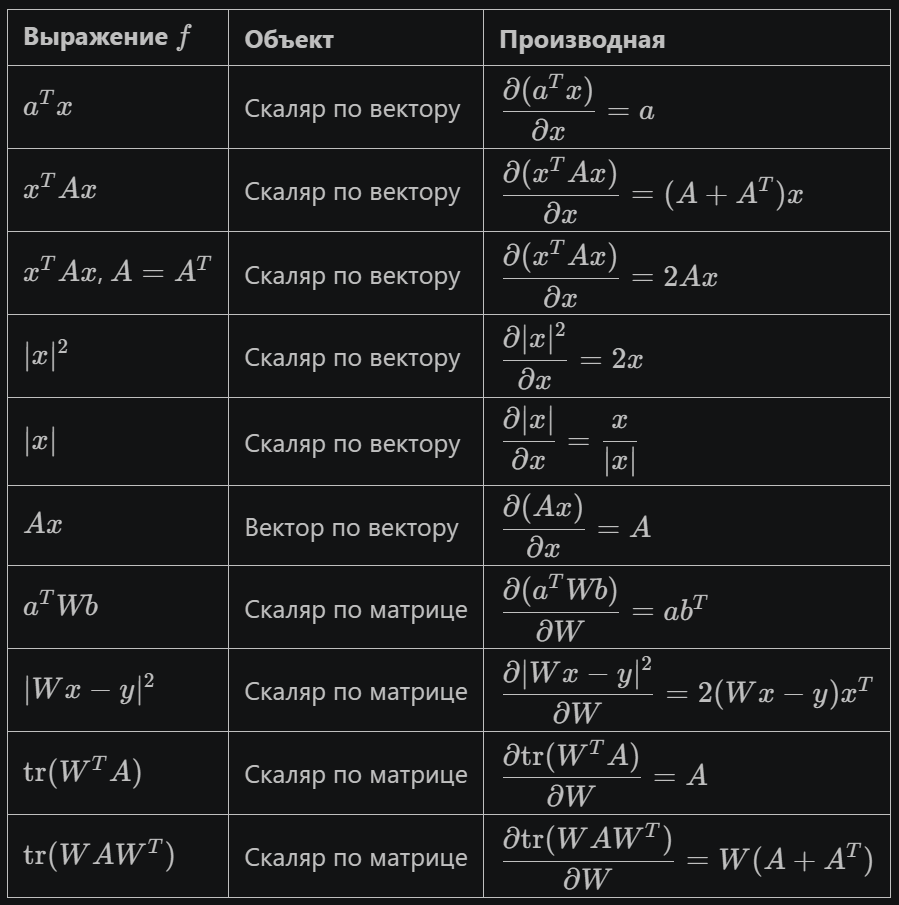

In [3]:
def num_grad_vector(f, v, h=1e-5):
    grad = np.zeros_like(v)

    for i in range(len(v)):
        v_plus, v_minus = v.copy(), v.copy()
        v_plus[i] += h
        v_minus[i] -= h
        grad[i] = (f(v_plus) - f(v_minus)) / (2 * h)
    return grad

def num_grad_matrix(f, M, h=1e-5):
    grad = np.zeros_like(M)

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            M_plus, M_minus = M.copy(), M.copy()
            M_plus[i, j] += h
            M_minus[i, j] -= h
            grad[i, j] = (f(M_plus) - f(M_minus)) / (2 * h)
    return grad

def jacobian_num(f, v, h=1e-5):
    n = len(v)
    f0 = f(v)
    m = len(f0)
    J = np.zeros((m, n))

    for i in range(n):
        v_plus, v_minus = v.copy(), v.copy()
        v_plus[i] += h
        v_minus[i] -= h
        J[:, i] = (f(v_plus) - f(v_minus)) / (2 * h)
    return J


m, n = 3, 4

x = np.random.randn(n)
y = np.random.randn(m)
a = np.random.randn(n)
b = np.random.randn(n)

A = np.random.randn(n, n)          # Для формул 2, 6
A_sym = (A + A.T) / 2             # Симметричная матрица для формулы 3
A_mn = np.random.randn(m, n)       # Для формулы 9
A_nn = np.random.randn(n, n)       # Для формулы 10
W = np.random.randn(m, n)          # Матрица весов для формул 7, 8, 9, 10

# Создаем специфичные векторы для формулы 7 (размерности должны подходить к W)
a_m = np.random.randn(m) 


# 1. f(x) = a^T x  =>  da^Tx/dx = a
f1 = lambda x: a.T @ x
grad_analytic_1 = a

# 2. f(x) = x^T A x  =>  dx^TAx/dx = (A + A^T)x
f2 = lambda x: x.T @ A @ x
grad_analytic_2 = (A + A.T) @ x

# 3. f(x) = x^T A x, A = A^T  =>  dx^TAx/dx = 2Ax
f3 = lambda x: x.T @ A_sym @ x
grad_analytic_3 = 2 * A_sym @ x

# 4. f(x) = ||x||^2  =>  d||x||^2/dx = 2x
f4 = lambda x: np.sum(x**2)
grad_analytic_4 = 2 * x

# 5. f(x) = ||x||  =>  d||x||/dx = x / ||x||
f5 = lambda x: np.linalg.norm(x)
grad_analytic_5 = x / np.linalg.norm(x)

# 6. f(x) = A x  =>  dAx/dx = A (Матрица Якоби вектор-функции)
f6 = lambda x: A @ x
grad_analytic_6 = A

# 7. f(W) = a^T W b  =>  da^TWb/dW = a b^T
f7 = lambda W: a_m.T @ W @ b
grad_analytic_7 = np.outer(a_m, b)

# 8. f(W) = ||W x - y||^2  =>  d||Wx-y||^2/dW = 2(Wx - y) x^T
f8 = lambda W: np.sum((W @ x - y)**2)
grad_analytic_8 = 2 * np.outer((W @ x - y), x)

# 9. f(W) = tr(W^T A)  =>  d tr(W^TA)/dW = A
f9 = lambda W: np.trace(W.T @ A_mn)
grad_analytic_9 = A_mn

# 10. f(W) = tr(W A W^T)  =>  d tr(WAW^T)/dW = W(A + A^T)
f10 = lambda W: np.trace(W @ A_nn @ W.T)
grad_analytic_10 = W @ (A_nn + A_nn.T)

func = [f1, f2, f3, f4, f5, f6, f7, f8, f9, f10]
grad_analytic = [grad_analytic_1, grad_analytic_2, grad_analytic_3,
                 grad_analytic_4, grad_analytic_5, grad_analytic_6,
                 grad_analytic_7, grad_analytic_8, grad_analytic_9,
                 grad_analytic_10]

for i, (f, grad) in enumerate(zip(func, grad_analytic), start=1):
    if i <= 5:
        grad_num = num_grad_vector(f, x)
    elif i == 6:
        grad_num = jacobian_num(f, x)
    else:
        grad_num = num_grad_matrix(f, W)
    
    diff = np.linalg.norm(grad - grad_num)
    print(f"Формула {i}:       Ошибка = {diff:.2e} | OK: {diff < 1e-5}")



Формула 1:       Ошибка = 2.52e-11 | OK: True
Формула 2:       Ошибка = 1.29e-10 | OK: True
Формула 3:       Ошибка = 1.50e-10 | OK: True
Формула 4:       Ошибка = 5.10e-11 | OK: True
Формула 5:       Ошибка = 2.42e-11 | OK: True
Формула 6:       Ошибка = 3.87e-11 | OK: True
Формула 7:       Ошибка = 5.34e-11 | OK: True
Формула 8:       Ошибка = 4.48e-10 | OK: True
Формула 9:       Ошибка = 5.76e-11 | OK: True
Формула 10:       Ошибка = 1.28e-10 | OK: True


---
2. **Якобиан softmax.** Выведите якобиан `softmax(z)` по `z`. Подсказка: `J_ij = s_i (δ_ij - s_j)`. Реализуйте на NumPy и сравните с численным.


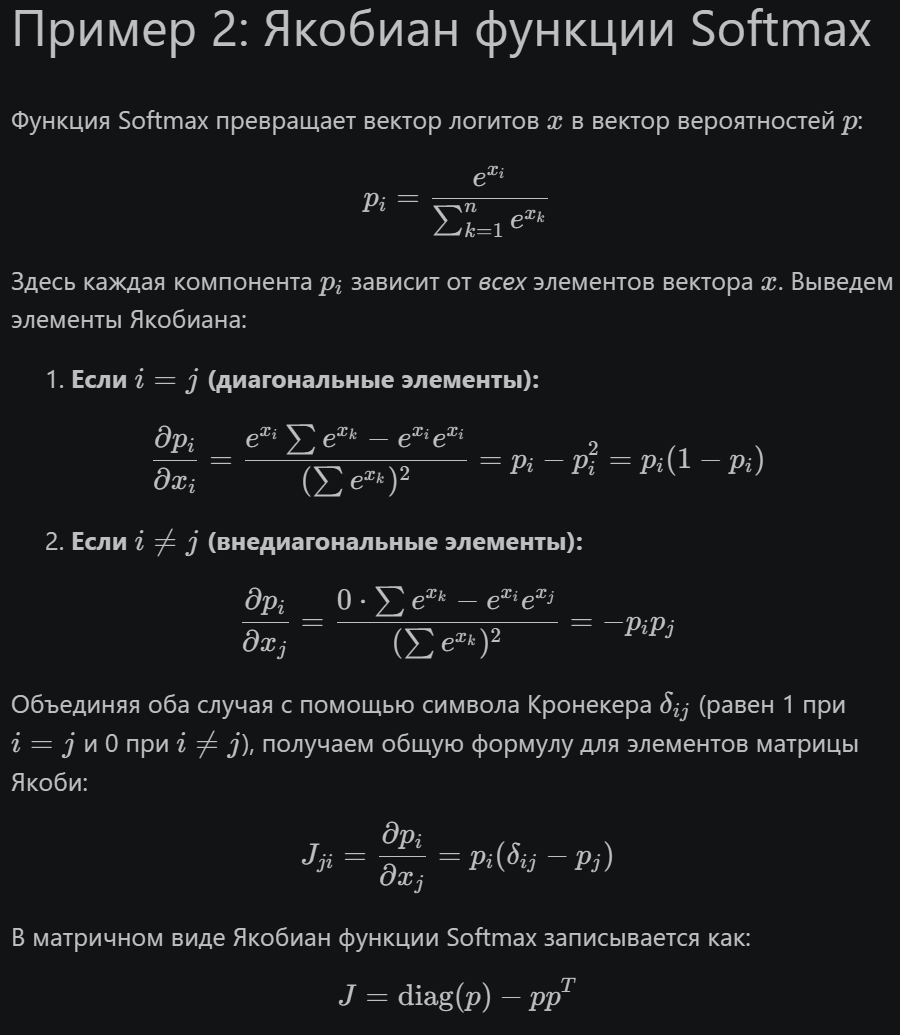

In [4]:
def softmax(z):
    shift_z = z - np.max(z)
    exps = np.exp(shift_z)
    return exps / np.sum(exps)

# numerator layout
def jacobian_num(f, v, h=1e-5):
    n = len(v)
    f0 = f(v)
    m = len(f0)
    J = np.zeros((m, n))

    for i in range(n):
        v_plus, v_minus = v.copy(), v.copy()
        v_plus[i] += h
        v_minus[i] -= h
        J[:, i] = (f(v_plus) - f(v_minus)) / (2 * h)
    return J

# denominator layout
def jacobian_num_ml(f, v, h=1e-5):
    n = len(v)
    f0 = f(v)
    m = len(f0)
    # Переворачиваем размерность под denominator layout: (переменные, функции)
    J = np.zeros((n, m))

    for i in range(n):
        v_plus, v_minus = v.copy(), v.copy()
        v_plus[i] += h
        v_minus[i] -= h
        # Записываем результат в строку i (производные всех функций по переменной i)
        J[i, :] = (f(v_plus) - f(v_minus)) / (2 * h)
    return J

def jacobian_softmax(z):
    return np.diag(z) - np.outer(z, z)

np.random.seed(42)

n = 5
v = np.random.randn(n)
v_softmax = softmax(v)
print(jacobian_num(softmax, v))
print(jacobian_softmax(v_softmax))

print(np.allclose(jacobian_num(softmax, v), jacobian_softmax(v_softmax)))


[[ 0.13953671 -0.01489316 -0.03268299 -0.07842917 -0.0135314 ]
 [-0.01489316  0.08094762 -0.01732025 -0.0415633  -0.00717092]
 [-0.03268299 -0.01732025  0.15695033 -0.09121053 -0.01573657]
 [-0.07842917 -0.0415633  -0.09121053  0.24896595 -0.03776295]
 [-0.0135314  -0.00717092 -0.01573657 -0.03776295  0.07420184]]
[[ 0.13953671 -0.01489316 -0.03268299 -0.07842917 -0.0135314 ]
 [-0.01489316  0.08094762 -0.01732025 -0.0415633  -0.00717092]
 [-0.03268299 -0.01732025  0.15695033 -0.09121053 -0.01573657]
 [-0.07842917 -0.0415633  -0.09121053  0.24896595 -0.03776295]
 [-0.0135314  -0.00717092 -0.01573657 -0.03776295  0.07420184]]
True


## Аналитический вывод Якобиана функции Softmax

Функция $\text{Softmax}$ отображает вектор логитов $z \in \mathbb{R}^n$ в вектор вероятностей $s \in \mathbb{R}^n$. Каждая $i$-я компонента выходного вектора вычисляется по формуле:

$$s_i = \frac{e^{z_i}}{\sum_{k=1}^n e^{z_k}}$$

Поскольку каждый выход $s_i$ зависит от абсолютно всех элементов входного вектора $z$, матрица Якоби (Якобиан) будет полностью заполненной. В соглашении **denominator layout** элемент матрицы на пересечении $j$-й строки и $i$-го столбца равен:

$$J_{ji} = \frac{\partial s_i}{\partial z_j}$$

Для нахождения производных применим стандартное правило дифференцирования дроби $\left(\frac{u}{v}\right)' = \frac{u'v - uv'}{v^2}$. Рассмотрим два возможных случая для индексов.

---

### Случай 1: Диагональные элементы ($i = j$)

Дифференцируем функцию $s_i$ по «своей» переменной $z_i$. В этом случае переменная $z_i$ присутствует и в числителе, и в знаменателе дроби:

$$\frac{\partial s_i}{\partial z_i} = \frac{\frac{\partial (e^{z_i})}{\partial z_i} \cdot \sum_{k=1}^n e^{z_k} - e^{z_i} \cdot \frac{\partial (\sum_{k=1}^n e^{z_k})}{\partial z_i}}{\left(\sum_{k=1}^n e^{z_k}\right)^2}$$

Так как $\frac{\partial (e^{z_i})}{\partial z_i} = e^{z_i}$, а в сумме знаменателя производная от всех слагаемых, кроме $e^{z_i}$, равна нулю, получаем:

$$\frac{\partial s_i}{\partial z_i} = \frac{e^{z_i} \sum_{k=1}^n e^{z_k} - e^{z_i} \cdot e^{z_i}}{\left(\sum_{k=1}^n e^{z_k}\right)^2}$$

Разбиваем полученную дробь на две отдельные части:

$$\frac{\partial s_i}{\partial z_i} = \frac{e^{z_i}}{\sum_{k=1}^n e^{z_k}} - \frac{e^{z_i}}{\sum_{k=1}^n e^{z_k}} \cdot \frac{e^{z_i}}{\sum_{k=1}^n e^{z_k}}$$

Вспоминаем исходное определение $s_i$ и делаем обратную замену:

$$\frac{\partial s_i}{\partial z_i} = s_i - s_i^2 = s_i(1 - s_i)$$

---

### Случай 2: Внедиагональные элементы ($i \neq j$)

Дифференцируем функцию $s_i$ по «чужой» переменной $z_j$. Теперь в числителе переменной $z_j$ нет (её производная равна 0), а в знаменателе она встречается ровно один раз в виде слагаемого $e^{z_j}$:

$$\frac{\partial s_i}{\partial z_j} = \frac{0 \cdot \sum_{k=1}^n e^{z_k} - e^{z_i} \cdot \frac{\partial (\sum_{k=1}^n e^{z_k})}{\partial z_j}}{\left(\sum_{k=1}^n e^{z_k}\right)^2}$$

$$\frac{\partial s_i}{\partial z_j} = \frac{-e^{z_i} \cdot e^{z_j}}{\left(\sum_{k=1}^n e^{z_k}\right)^2}$$

Выделим две независимые дроби из этого произведения:

$$\frac{\partial s_i}{\partial z_j} = - \left( \frac{e^{z_i}}{\sum_{k=1}^n e^{z_k}} \right) \cdot \left( \frac{e^{z_j}}{\sum_{k=1}^n e^{z_k}} \right)$$

Подставляем значения $s_i$ и $s_j$:

$$\frac{\partial s_i}{\partial z_j} = -s_i s_j$$

---

### Объединение в общую формулу

Для компактной записи объединим оба случая с помощью **символа Кронекера** $\delta_{ij}$, который равен $1$ при $i=j$ и $0$ при $i \neq j$:

$$J_{ji} = \frac{\partial s_i}{\partial z_j} = s_i(\delta_{ij} - s_j)$$

### Переход к матричной форме в NumPy

Чтобы избавиться от циклов и векторизовать вычисления, переведем формулу на язык линейной алгебры:
1. Часть $s_i \delta_{ij}$ оставляет элементы вектора $s$ только на главной диагонали матрицы $\to$ `np.diag(s)`.
2. Часть $-s_i s_j$ формирует матрицу всевозможных парных произведений через внешнее произведение (outer product) векторов $\to$ `np.outer(s, s)`.

Поскольку результирующая матрица полностью симметрична ($J = J^T$), порядок индексов $J_{ji}$ совпадает с матричной записью. Итоговый аналитический код принимает вид:

$$J = \text{diag}(s) - s s^T$$


---
---
3. **Градиент линейной регрессии.** Реализуйте `grad_linreg(X, y, w)`. Обучите GD на синтетических данных. Сравните с решением через `np.linalg.solve`.


In [5]:
np.random.seed(42)

N, D = 200, 3

# 1. Генерация матрицы признаков X (добавляем константный признак для bias - без единичного столбца)
X_raw = np.random.randn(N, D)
X = np.hstack([np.ones((N, 1)), X_raw]) # Теперь размерность X: (200, 4)

# 2. Истинные веса w_true (bias + 3 коэффициента)
w_true = np.array([1.5, -2.0, 0.5, 3.1])

# 3. Генерация целевой переменной y с добавлением случайного Гауссовского шума
noise = np.random.randn(N) * 0.2
y = X @ w_true + noise

# 4. Начальная точка весов для Градиентного Спуска (GD)
w_start = np.random.randn(D + 1)


def grad_linreg(X, y, w):
    return (2 / N) * X.T @ (X @ w - y)

def grad_descence(grad, w0, lr=0.1, steps=1000):
    w = w0.copy()
    history = [w.copy()]
    for _ in range(steps):
        w = w - lr * grad(X, y, w)
        history.append(w)
    return w, np.array(history)

w_numerical, hist = grad_descence(grad_linreg, w0=w_start)
w_numpy = np.linalg.solve(X.T @ X, X.T @ y)
print(w_true)
print(w_numerical)
print(w_numpy)
print(np.allclose(w_numerical, w_numpy))

# print(hist)




[ 1.5 -2.   0.5  3.1]
[ 1.50376478 -2.00476747  0.51847393  3.12370895]
[ 1.50376478 -2.00476747  0.51847393  3.12370895]
True


4. **Градиент logistic regression.** Реализуйте `grad_logreg(X, y, w)` и обучите классификатор на двух классах из Iris. Точность должна быть >95%.


In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
X_raw = iris.data
y_raw = iris.target
# print(X.shape)
# print(y_raw.shape)

mask = y_raw < 2
X = X_raw[mask]
y = y_raw[mask]

np.random.seed(42)
w_start = np.random.randn(X.shape[1])

def sigmoid(z):
    return 1.0 / (1 + np.exp(-z))

def grad_logreg(X, y, w):
    N = X.shape[0]
    return (1.0 / N) * X.T @ (sigmoid(X @ w) - y)

def grad_descence(grad, w0, lr=0.1, steps=1000):
    w = w0.copy()
    history = [w.copy()]
    for _ in range(steps):
        w = w - lr * grad(X, y, w)
        history.append(w)
    return w, np.array(history)

w, hist = grad_descence(grad_logreg, w_start)

# Подсчет accuracy
# Сначала получаем вероятности с помощью наших предсказанных весов
# Превращаем вероятности в классы с помощью маски
# Сравниваем полученные классы с истинными
y_pred_probability = sigmoid(X @ w)
y_pred_classes = (y_pred_probability >= 0.5).astype(int)
accuracy = np.mean(y_pred_classes == y)
print(accuracy)


1.0


# Логистическая регрессия (Logistic Regression)

**Логистическая регрессия** — это базовый параметрический метод **классификации**, который предсказывает вероятность принадлежности объекта к определенному классу (чаще всего бинарному: $0$ или $1$). 

Несмотря на слово «регрессия» в названии, алгоритм решает задачу дискретного разделения данных. Его суть заключается в том, что он берет непрерывное предсказание линейной регрессии и сжимает его в диапазон $[0, 1]$ с помощью сигмоиды.

---

## Математический фундамент модели

Процесс работы модели на этапе предсказания состоит из трех последовательных шагов:

### 1. Линейная комбинация признаков
Входной вектор признаков $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$ умножается на вектор весов $\mathbf{w} = [w_1, w_2, \dots, w_n]^T$ с добавлением свободного коэффициента (сдвига) $b$:
$$z = \mathbf{x}^T\mathbf{w} + b = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$
Переменная $z$ (называемая *логитом*) может принимать любое вещественное значение от $-\infty$ до $+\infty$.

### 2. Активация Сигмоидой (Sigmoid)
Чтобы превратить произвольное число $z$ в вероятность, его пропускают через логистическую функцию:
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

* Если $z \to +\infty$, то $e^{-z} \to 0$, и $\sigma(z) \to 1$.
* Если $z \to -\infty$, то $e^{-z} \to +\infty$, и $\sigma(z) \to 0$.
* Если $z = 0$, то $\sigma(0) = 0.5$.

### 3. Переход к жестким классам
Полученное значение $\hat{y} = \sigma(z)$ — это вероятность $P(y=1 \mid \mathbf{x})$. Финальный класс определяется через пороговую функцию:
$$\text{Class} = \begin{cases} 1, & \text{если } \hat{y} \ge 0.5 \\ 0, & \text{если } \hat{y} < 0.5 \end{cases}$$

---

## Функция потерь (Log-Loss / Бинарная кросс-энтропия)

В линейной регрессии используется среднеквадратичная ошибка (MSE). Если применить MSE к логистической регрессии, функция потерь станет невыпуклой (non-convex) с огромным количеством ложных локальных минимумов, где градиентный спуск застрянет.

Поэтому используют функцию логистических потерь **Log-Loss**:
$$L(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^N \Big[ y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i) \Big]$$

где $y_i$ — реальный класс ($0$ или $1$), а $\hat{y}_i = \sigma(\mathbf{X}_i \mathbf{w} + b)$ — предсказанная вероятность.

---

## Вычисление градиента (Связь с матричным исчислением)

Чтобы обучить модель, необходимо минимизировать Log-Loss. Для этого вычисляется производная скаляра (значения ошибки $L$) по вектору весов $\mathbf{w}$. Используя принятое в машинном обучении *соглашение знаменателя (denominator layout)*, мы получаем вектор градиента той же формы, что и веса.

По правилу цепочки (Chain Rule) производная сложной функции раскрывается и сокращается до лаконичного матричного вида:
$$\nabla_{\mathbf{w}} L = \frac{1}{N} \mathbf{X}^T (\sigma(\mathbf{X}\mathbf{w}) - y)$$

* Вектор $(\sigma(\mathbf{X}\mathbf{w}) - y)$ — это вектор ошибок (разница между предсказанной вероятностью и реальной меткой).
* Умножение на транспонированную матрицу признаков $\mathbf{X}^T$ распределяет эту ошибку по каждому конкретному весу.


---
---
5. **Гессиан 2D-функции.** Постройте контурный график `f(x, y) = x² + 3y² − 2xy`. Посчитайте гессиан. Является ли точка (0,0) минимумом?


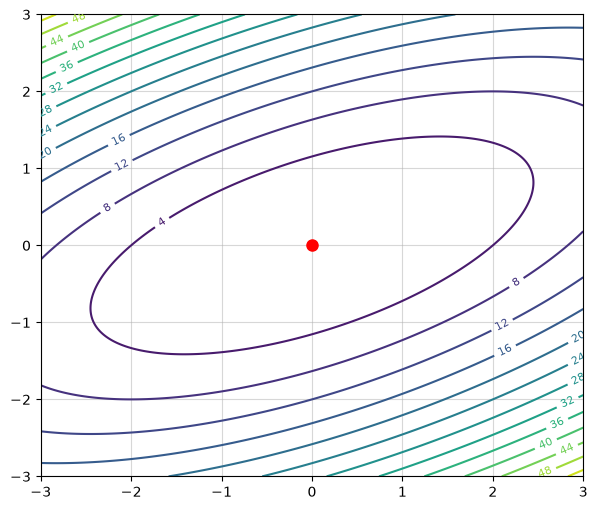

Результат: Все собственные значения > 0. Точка (0,0) — СТРОГИЙ МИНИМУМ.


In [25]:
from matplotlib import pyplot as plt


def grad_f(v):
    x, y = v
    grad_x = 2 * x - 2 * y
    grad_y = 6 * y - 2 * x
    return np.array([grad_x, grad_y])

def jacobian(f_vector, v, h=1e-5):
    n = len(v)
    func = f_vector(v)
    m = len(func)
    J = np.zeros((m, n))

    for i in range(n):
        v_p, v_m = v.copy(), v.copy()
        v_p[i] += h
        v_m[i] -= h
        J[:, i] = (f_vector(v_p) - f_vector(v_m)) / (2 * h)

    return J
    
def f(x, y):
    return x ** 2 + 3 * y ** 2 - 2 * x * y

v_point = np.array([0.0, 0.0])
H_num = jacobian(grad_f, v_point)

H_analytic = np.array([
    [2.0, -2.0],
    [-2.0, 6.0]
])
# print(np.allclose(H_analytic, H_num))

X_range = np.linspace(-3, 3, 200)
Y_range = np.linspace(-3, 3, 1000)
X, Y = np.meshgrid(X_range, Y_range)
Z = f(X, Y)

plt.figure(figsize=(7, 6))
contours = plt.contour(X, Y, Z, levels=15, cmap="viridis")
plt.clabel(contours, inline=True, fontsize=8)
plt.plot(0, 0, 'o', markersize=8, color="red")
plt.grid(True, alpha=0.5)
plt.show()

eigval = np.linalg.eigvals(H_num)

if np.all(eigval > 0):
    print("Результат: Все собственные значения > 0. Точка (0,0) — СТРОГИЙ МИНИМУМ.")
elif np.all(eigval < 0):
    print("Результат: Все собственные значения < 0. Точка (0,0) — СТРОГИЙ МАКСИМУМ.")
else:
    print("Результат: Собственные значения разных знаков. Точка (0,0) — СЕДЛОВАЯ ТОЧКА.")


### Визуальный анализ критических точек по контурному графику

Контурный график (линии уровня) позволяет мгновенно определить характер критической точки без вычисления матрицы Гессе. Для этого достаточно проследить, как меняются числовые значения на изолиниях по мере удаления от исследуемой точки $(x_0, y_0)$:

1. **Локальный минимум (Чаша)**
   * **Геометрия линий:** Вокруг точки образуются замкнутые, концентрические кольца (эллипсы или окружности).
   * **Поведение значений:** Числа на линиях уровня строго **возрастают** по мере удаления от центра к краям. Точка находится на самом «дне» топографической впадины.
   * *Для нашей функции:* Вокруг точки $(0,0)$ значения контуров последовательно увеличиваются ($0.5 \to 1.0 \to 2.0 \to \dots$), что наглядно подтверждает наличие минимума.

2. **Локальный максимум (Пик)**
   * **Геометрия линий:** Линии также представляют собой замкнутые концентрические кольца.
   * **Поведение значений:** Числа на изолиниях строго **убывают** при движении от центра к периферии. Точка является «вершиной горы».

3. **Седловая точка (Перевал)**
   * **Геометрия линий:** Линии уровня не образуют колец вокруг точки. Вместо этого они напоминают гиперболы, образуя характерный крест или «песочные часы» (две ветви сходятся, две расходятся).
   * **Поведение значений:** Вдоль одного направления (оси) значения функций растут, а вдоль перпендикулярного направления — падают. Оптимизационный алгоритм в такой точке может застрять.

---


# Фундаментальная теория: Якобиан и Гессиан в Машинном Обучении

В многомерном анализе и оптимизации производные делятся по порядку и по типу объектов. 
Если **градиент** работает со скалярными функциями первого порядка, то **Якобиан** и **Гессиан** обобщают понятия производных на векторные функции и вторые порядки.

Все формулы ниже представлены в стандартном для ML соглашении **denominator layout** (размерность производной совпадает с размерностью знаменателя).

---

## 1. ЯКОБИАН (Матрица Якоби)

### Что это такое?
**Якобиан** — это матрица, содержащая все частные производные первого порядка для вектор-функции. 

Если функция $f: \mathbb{R}^n \to \mathbb{R}^m$ принимает на вход вектор $x$ из $n$ элементов, а на выходе выдает вектор из $m$ элементов, то её Якобиан $J$ — это матрица размером $n \times m$:

$$J = \frac{\partial f}{\partial x} = \begin{pmatrix} 
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_2}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_1} \\ 
\frac{\partial f_1}{\partial x_2} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_2} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
\frac{\partial f_1}{\partial x_n} & \frac{\partial f_2}{\partial x_n} & \cdots & \frac{\partial f_m}{\partial x_n} 
\end{pmatrix}$$

### Связь с дифференциалом
Матрицу Якоби проще всего находить через полный дифференциал вектор-функции, приводя его к канонической форме:
$$df = J^T dx$$

### Зачем нужен Якобиан в ML?
1. **Обратное распространение ошибки (Backpropagation):** При прохождении градиента через многомерный слой нейросети (например, Softmax или скрытый линейный слой) промежуточный шаг дифференцирования сложной функции (Chain Rule) требует умножения на Якобиан этого слоя:
   $$\frac{\partial L}{\partial x} = J_{layer} \cdot \frac{\partial L}{\partial y}$$
2. **Генеративные модели (Normalizing Flows):** Модели нормализационных потоков используют модуль определителя Якобиана $|\det(J)|$ для точного пересчета плотности вероятностей при деформации пространства из простого шума в реальные данные.
3. **Устойчивость и регуляризация:** Штрафование модели за слишком большую норму Фробениуса её Якобиана ($\|J\|_F^2$) заставляет нейросеть быть плавной и не реагировать на мелкий шум во входных данных (защита от состязательных атак).

---

## 2. ГЕССИАН (Матрица Гессе)

### Что это такое?
**Гессиан** — это квадратная симметричная матрица, состоящая из частных производных второго порядка скалярной функции $f: \mathbb{R}^n \to \mathbb{R}$.

Если градиент показывает направление наискорейшего роста (информация 1-го порядка), то Гессиан описывает **кривизну** (информация 2-го порядка) оптимизируемой поверхности. Матрица имеет размерность $n \times n$:

$$H = \nabla^2 f(x) = \begin{pmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \frac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_1 \partial x_n} \\
\frac{\partial^2 f}{\partial x_2 \partial x_1} & \frac{\partial^2 f}{\partial x_2^2} & \cdots & \frac{\partial^2 f}{\partial x_2 \partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial^2 f}{\partial x_n \partial x_1} & \frac{\partial^2 f}{\partial x_n \partial x_2} & \cdots & \frac{\partial^2 f}{\partial x_n^2}
\end{pmatrix}$$

*Важно:* Гессиан — это **Якобиан от градиента**. Матрица всегда симметрична ($H = H^T$), если вторые производные непрерывны (теорема Шварца).

### Связь с дифференциалом
Второй дифференциал скалярной функции приводится к следующему каноническому виду, откуда считывается Гессиан:
$$d^2 f = dx^T \cdot H \cdot dx$$

---

## 3. ЧТО МОЖНО ОПРЕДЕЛЯТЬ С ПОМОЩЬЮ ГЕССИАНА?

Главная математическая сила Гессиана — способность проводить **анализ характера критических точек** (где градиент равен нулю: $\nabla f(x) = 0$). 

Характер точки определяется по знакам **собственных значений ($\lambda$)** матрицы Гессе (или по критерию Сильвестра через угловые миноры):

| Условие на собственные значения $\lambda$ | Математический статус | Тип критической точки | Визуальный рельеф |
| :--- | :--- | :--- | :--- |
| **Все $\lambda > 0$** | Положительно определенная ($H > 0$) | **Строгий локальный минимум** | Дно чаши / впадина |
| **Все $\lambda < 0$** | Отрицательно определенная ($H < 0$) | **Строгий локальный максимум** | Вершина горы / пик |
| **Есть и $\lambda > 0$, и $\lambda < 0$** | Знакопеременная | **Седловая точка** | Горный перевал |
| **Есть $\lambda = 0$ (остальные $>0$ или $<0$)** | Полуопределенная | Вырожденный случай | Требует анализа высших производных |

### Зачем нужен Гессиан в ML?
1. **Методы оптимизации второго порядка (Метод Ньютона):** 
   Вместо того чтобы делать мелкие шаги по направлению градиента, метод Ньютона аппроксимирует функцию параболоидом и прыгает сразу в её теоретический экстремум. Формула обновления весов:
   $$w_{new} = w_{old} - H^{-1} \cdot \nabla f(w_{old})$$
   *Проблема в DL:* Для нейросети с $10^9$ параметров матрица Гессе будет иметь размер $10^9 \times 10^9$. Её невозможно ни вычислить, ни сохранить в памяти, поэтому применяются квазиньютоновские методы (L-BFGS).
2. **Градиентный бустинг (XGBoost, LightGBM):**
   Строят деревья решений, раскладывая произвольные функции потерь в ряд Тейлора до второго порядка. Для вычисления оптимального сдвига в листах деревьев бустинг складывает первые производные (градиенты $g_i$) и вторые производные (элементы Гессиана $h_i$) функции потерь.
3. **Борьба с седловыми точками:**
   В глубоких нейросетях подавляющее большинство критических точек — это не локальные минимумы, а седловые точки. Обычный градиентный спуск в них застревает, так как градиент падает до нуля. Анализ собственных значений Гессиана позволяет алгоритмам находить направления с отрицательной кривизной ($\lambda < 0$) и «стекать» по ним дальше вниз, продолжая обучение.


---

# Математический анализ Гессиана: Собственные значения и Критерий Сильвестра

Когда мы нашли критическую точку (где градиент равен нулю: $\nabla f(x) = 0$), нам нужно строго определить её характер. Для этого проверяется **знакоопределенность** матрицы Гессе $H$. Существует два главных практических способа сделать это: через собственные значения или через критерий Сильвестра.

---

## 1. Как найти собственные значения Гессиана

**Собственные значения** ($\lambda$) матрицы $H$ — это числа, которые показывают, во сколько раз растягивается вектор $dx$ при умножении на эту матрицу в определенных (главных) направлениях: $H \cdot dx = \lambda \cdot dx$.

### Алгоритм вычисления (Характеристическое уравнение)
Чтобы найти $\lambda$ вручную, необходимо решить матричное уравнение:

$$\det(H - \lambda I) = 0$$

Где $I$ — единичная матрица того же размера, что и $H$.

#### Пример для Гессиана нашей 2D-функции:
Наш Гессиан равен $H = \begin{pmatrix} 2 & -2 \\ -2 & 6 \end{pmatrix}$. Составим характеристическое уравнение:

$$\det \begin{pmatrix} 2 - \lambda & -2 \\ -2 & 6 - \lambda \end{pmatrix} = 0$$

Раскрываем определитель матрицы $2 \times 2$:
$$(2 - \lambda)(6 - \lambda) - (-2 \cdot -2) = 0$$
$$12 - 2\lambda - 6\lambda + \lambda^2 - 4 = 0$$
$$\lambda^2 - 8\lambda + 8 = 0$$

Решаем квадратное уравнение через дискриминант ($D = 64 - 4 \cdot 1 \cdot 8 = 32$):
$$\lambda_{1, 2} = \frac{8 \pm \sqrt{32}}{2} = 4 \pm 2\sqrt{2}$$

Поскольку $\sqrt{32} \approx 5.65$, оба корня строго положительны:
$$\lambda_1 \approx 6.83 > 0, \quad \lambda_2 \approx 1.17 > 0$$

**Вывод:** Так как абсолютно все собственные значения больше нуля ($\lambda > 0$), матрица $H$ положительно определена. Кривизна поверхности во всех направлениях идет вверх — точка $(0,0)$ является **строгим локальным минимумом**.

---

## 2. Что такое Критерий Сильвестра

**Критерий Сильвестра** — это альтернативный, более быстрый способ определить знакоопределенность матрицы. Он избавляет от необходимости решать сложные полиномиальные уравнения и искать точные корни $\lambda$. Вместо этого вычисляются **угловые (главные) миноры** матрицы.

Угловые миноры $\Delta_k$ — это определители квадратных подматриц, расположенных в левом верхнем углу исходной матрицы $H$:
* $\Delta_1$ — элемент $H_{11}$
* $\Delta_2$ — определитель матрицы $2 \times 2$ в левом верхнем углу
* $\Delta_n$ — определитель всей матрицы $H$ ($\det(H)$)

### Правила критерия Сильвестра:

1. **Положительно определенная матрица (Локальный МИНИМУМ):**
   Все угловые миноры строго больше нуля.
   $$\Delta_1 > 0, \quad \Delta_2 > 0, \quad \dots, \quad \Delta_n > 0$$

2. **Отрицательно определенная матрица (Локальный МАКСИМУМ):**
   Знаки угловых миноров строго чередуются, начиная с минуса.
   $$\Delta_1 < 0, \quad \Delta_2 > 0, \quad \Delta_3 < 0, \quad \dots$$

3. **Знакопеременная матрица (СЕДЛОВАЯ точка):**
   Если знаки миноров нарушают первые два правила (например, $\Delta_2 < 0$), то матрица знакопеременная, и в этой точке находится перевал.

#### Проверка нашей матрицы по Сильвестру:
Матрица $H = \begin{pmatrix} \mathbf{2} & -2 \\ -2 & 6 \end{pmatrix}$.

1. Первый минор (левый верхний угол): 
$$\Delta_1 = 2 > 0$$
2. Второй минор (определитель всей матрицы): 
$$\Delta_2 = \det(H) = (2 \cdot 6) - (-2 \cdot -2) = 12 - 4 = 8 > 0$$

**Вывод:** Оба минора положительны ($\Delta_1 > 0, \Delta_2 > 0$). Критерий Сильвестра подтверждает, что исследуемая точка — **локальный минимум**.


---

6. **Метод Ньютона.** Реализуйте: `x ← x − H⁻¹ ∇f`. Сравните скорость сходимости с обычным GD на квадратичной функции.


In [51]:
import time


def f(x):
    return x[0]**2 + 10 * x[1]**2

def grad_f(x):
    return np.array([2 * x[0], 20 * x[1]])

def hessian_f(x):
    # Для квадратичной функции Гессиан константен и состоит из чистых чисел
    return np.array([[2.0, 0.0], 
                     [0.0, 20.0]])

# Градиентный спуск (GD)
def gradient_descent(grad, x0, lr=0.05, eps=1e-5, max_steps=10000):
    x = x0.copy()
    steps = 0
    for _ in range(max_steps):
        g = grad(x)
        if np.linalg.norm(g) < eps:  # Критерий сходимости
            break
        x = x - lr * g
        steps += 1
    return x, steps

# Метод Ньютона
def newton_method(grad, hessian, x_start, eps=1e-5, max_steps=100):
    x = x_start.copy()
    steps = 0
    for _ in range(max_steps):
        g = grad(x)
        if np.linalg.norm(g) < eps:  # Критерий сходимости
            break
        H = hessian(x)
        delta_x = np.linalg.solve(H, -g)
        x = x + delta_x
        steps += 1
    return x, steps

start_point = np.array([10.0, -5.0])

start_grad = time.time()
x_grad = gradient_descent(grad_f, start_point)
end_grad = time.time()
print(x_grad, end_grad - start_grad)

start_newton = time.time()
x_newton = newton_method(grad_f, hessian_f, start_point)
end_newton = time.time()
print(x_newton, end_newton - start_newton)



(array([4.84692503e-06, 0.00000000e+00]), 138) 0.002375364303588867
(array([0., 0.]), 1) 0.0002541542053222656


7. **Ridge regression.** Выведите формулу для `w` в задаче `||Xw - y||² + λ||w||²`. Реализуйте и покажите, что при `λ > 0` система решается даже при вырожденной `X^T X`.


## 7. Ridge-регрессия (Гребневая регрессия)

Задачей Ridge-регрессии является минимизация функции потерь, содержащей квадратичный штраф за величину весов ($L_2$-регуляризация):
$$L(\mathbf{w}) = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2 + \lambda\|\mathbf{w}\|^2$$

---

## Математический вывод аналитического решения

Для вывода оптимального вектора весов $\mathbf{w}$ перепишем нормы через матричное умножение (вспомнив, что $\|\mathbf{v}\|^2 = \mathbf{v}^T \mathbf{v}$):

$$L(\mathbf{w}) = (\mathbf{X}\mathbf{w} - \mathbf{y})^T (\mathbf{X}\mathbf{w} - \mathbf{y}) + \lambda \mathbf{w}^T \mathbf{w}$$

Раскроем скобки в первом слагаемом:
$$L(\mathbf{w}) = (\mathbf{w}^T \mathbf{X}^T - \mathbf{y}^T)(\mathbf{X}\mathbf{w} - \mathbf{y}) + \lambda \mathbf{w}^T \mathbf{w}$$
$$L(\mathbf{w}) = \mathbf{w}^T \mathbf{X}^T \mathbf{X} \mathbf{w} - \mathbf{w}^T \mathbf{X}^T \mathbf{y} - \mathbf{y}^T \mathbf{X} \mathbf{w} + \mathbf{y}^T \mathbf{y} + \lambda \mathbf{w}^T \mathbf{w}$$

Так как $\mathbf{w}^T \mathbf{X}^T \mathbf{y}$ и $\mathbf{y}^T \mathbf{X} \mathbf{w}$ — это одинаковые скалярные величины, объединим их:
$$L(\mathbf{w}) = \mathbf{w}^T \mathbf{X}^T \mathbf{X} \mathbf{w} - 2\mathbf{w}^T \mathbf{X}^T \mathbf{y} + \mathbf{y}^T \mathbf{y} + \lambda \mathbf{w}^T \mathbf{w}$$

Возьмем градиент по вектору весов $\mathbf{w}$ (в соглашении знаменателя):
$$\nabla_{\mathbf{w}} L = 2 \mathbf{X}^T \mathbf{X} \mathbf{w} - 2 \mathbf{X}^T \mathbf{y} + 2 \lambda \mathbf{w}$$

Приравняем градиент к нулевому вектору для поиска экстремума:
$$2 \mathbf{X}^T \mathbf{X} \mathbf{w} - 2 \mathbf{X}^T \mathbf{y} + 2 \lambda \mathbf{w} = \mathbf{0}$$

Разделим уравнение на 2 и сгруппируем слагаемые с $\mathbf{w}$. Чтобы корректно сложить матрицу со скаляром $\lambda$, умножим его на единичную матрицу $\mathbf{I}$:
$$(\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I}) \mathbf{w} = \mathbf{X}^T \mathbf{y}$$

Умножив обе части слева на обратную матрицу, получаем искомую формулу:
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

---

## Почему система стабильно решается только при $\lambda > 0$?

Матрица Грама $\mathbf{A} = \mathbf{X}^T \mathbf{X}$ всегда является полуположительно определенной. Это означает, что все её собственные значения неотрицательны ($\mu_i \ge 0$). 

Если матрица $\mathbf{X}^T \mathbf{X}$ **вырождена** (например, из-за мультиколлинеарности или когда признаков больше, чем объектов), то как минимум одно её собственное значение строго равно нулю ($\mu_{\min} = 0$). Определитель такой матрицы равен нулю ($\det(\mathbf{X}^T \mathbf{X}) = 0$), и вычислить обратную матрицу невозможно.

При добавлении регуляризатора $\lambda \mathbf{I}$ новые собственные значения матрицы становятся равными:
$$\mu_{\text{new}} = \mu_i + \lambda$$

### 1. Случай $\lambda > 0$ (Стабилизация)
Даже самое минимальное (нулевое) собственное значение сдвигается в положительную сторону: $0 + \lambda = \lambda > 0$. Все остальные собственные значения также увеличиваются. Результирующая матрица $(\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})$ гарантированно становится **строго положительно определенной**. Её определитель строго больше нуля, она становится **всегда обратимой**, а система имеет единственное стабильное решение.

### 2. Случай $\lambda < 0$ (Разрушение)
При отрицательных $\lambda$ мы вычитаем значения из диагонали. Это приводит к двум катастрофическим последствиям:
* Для какого-то изначально ненулевого собственного значения $\mu_k$ может возникнуть ситуация, когда $\mu_k + \lambda = 0$. Это сделает матрицу еще более вырожденной.
* Функция потерь теряет свойство выпуклости и перестает стремиться к $+\infty$ на краях, из-за чего задача поиска глобального минимума теряет физический и математический смысл.


---
# Почему матрица Грама всегда полуположительно определенная?

Матрица Грама всегда является полуположительно определенной из-за фундаментального свойства **квадрата длины вектора** в линейной алгебре: длина любого вектора (или скалярное произведение вектора на самого себя) никогда не может быть отрицательной.

---

### Математическое доказательство

Пусть у нас есть матрица $X$, столбцами которой являются наши векторы $x_1, x_2, \dots, x_n$. Тогда матрица Грама $G$ вычисляется как скалярное произведение всех пар векторов, что в матричном виде записывается как:
$$G = X^T X$$

По определению, симметричная матрица $G$ называется **полуположительно определенной**, если для любого произвольного вектора-столбца $u$ выполняется условие:
$$u^T G u \ge 0$$

Давайте подставим определение матрицы Грама ($G = X^T X$) в это квадратичное выражение и сгруппируем элементы:

1. Записываем выражение:  
   $$u^T G u = u^T (X^T X) u$$
2. Используя свойство транспонирования $(AB)^T = B^T A^T$, мы можем объединить первые два множителя:  
   $$u^T X^T = (Xu)^T$$
3. Подставляем это обратно и получаем:  
   $$u^T G u = (Xu)^T (Xu)$$

---

### Геометрический смысл результата

Выражение $(Xu)^T (Xu)$ — это не что иное, как **скалярное произведение вектора $Xu$ на самого себя**. А скалярное произведение любого вектора на самого себя равняется квадрату его евклидовой длины (нормы):
$$(Xu)^T (Xu) = \|Xu\|^2$$

Поскольку квадрат длины любого реального вектора в евклидовом пространстве математически **никогда не может быть меньше нуля**, мы получаем финальное неравенство:
$$u^T G u = \|Xu\|^2 \ge 0$$

Условие полностью выполнено. Именно поэтому матрица Грама абсолютно всегда является полуположительно определенной (обозначается как $G \succeq 0$).

---

### Когда матрица становится строго положительно определенной ($> 0$)?

* **Линейная независимость ($G \succ 0$):** Если исходные векторы $x_1, x_2, \dots, x_n$ линейно независимы, то вектор $Xu$ может стать нулевым только в одном случае — если сам вектор $u$ является строго нулевым. Для всех остальных векторов результат будет строго больше нуля ($>0$).
* **Линейная зависимость ($G \succeq 0$):** Если среди исходных векторов есть линейно зависимые (например, один вектор является копией другого или их суммой), то длина $\|Xu\|^2$ сможет занулиться даже при ненулевом векторе $u$. В этом случае матрица останется *полуположительно* определенной, а её определитель (детерминант) будет равен $0$.


---

In [69]:
def ridge(X, y, lam):
    A = X.T @ X
    I = np.eye(A.shape[0])
    return np.linalg.solve(A + lam * I, X.T @ y)


np.random.seed(42)

n, m = 100, 3
X_clean = np.random.randn(n, m - 1)
X_depended = X_clean[:, [1]] # скобки для сложного индексирования (чтобы вернулся столбец, а не строка)

X = np.hstack([X_clean, X_depended]) # есть лин. зав. строки
w_true = np.array([2.0, -1.0, 0.0])
y = X @ w_true + np.random.randn(n) * 0.1

A = X.T @ X
# print(np.linalg.det(A))

try:
    w_ordinary_linreg = ridge(X, y, lam=0.0)
    print(f"При lambda = 0.0 веса найдены: {w_ordinary_linreg}")
except np.linalg.LinAlgError:
    print("При lambda = 0.0 возникла ошибка")

try:
    w_ridge = ridge(X, y, lam=0.1)
    print(f"При lambda = 0.1 веса найдены: {w_ridge}")
except np.linalg.LinAlgError:
    print("При lambda = 0.1 возникла ошибка")

try:
    # Ищем такую лямбду в СИММЕТРИЧНОЙ (h - hermitian), которая совпадет с одним из собственных значений
    eigenvalues = np.linalg.eigvalsh(A)
    bad_lam = -eigenvalues[1] # Берем ненулевое собственное значение с минусом
    w_negative = ridge(X, y, lam=bad_lam)
    A_bad = A + bad_lam * np.eye(A.shape[0])

    if np.linalg.cond(A_bad) > 1e12:
        raise np.linalg.LinAlgError("Матрица численно вырождена (число обусловленности слишком велико)!")
    else:
        print(f"При lambda = {bad_lam:.4f} веса найдены: {w_negative}")
except np.linalg.LinAlgError:
    print(f"При lambda = {bad_lam:.4f}: Матрица снова вырождена! Решение упало.")


При lambda = 0.0 возникла ошибка
При lambda = 0.1 веса найдены: [ 2.01486655 -0.50814072 -0.50814072]
При lambda = -73.8408: Матрица снова вырождена! Решение упало.


8. **Backprop линейного слоя.** Для слоя `y = Wx + b` выведите `∂L/∂W`, `∂L/∂b`, `∂L/∂x` через известный `∂L/∂y`. Сравните с тем, что делает PyTorch.


In [70]:
import torch

M, N = 3, 4
np.random.seed(42)

x_np = np.random.randn(N, 1)
W_np = np.random.randn(M, N)
b_np = np.random.randn(M, 1)
dL_dy_np = np.random.randn(M, 1)  # Пришедший градиент

dL_dW_np = dL_dy_np @ x_np.T        # Матричное умножение (M, 1) x (1, N) -> (M, N)
dL_db_np = dL_dy_np.copy()          # Вектор (M, 1)
dL_dx_np = W_np.T @ dL_dy_np        # Матричное умножение (N, M) x (M, 1) -> (N, 1)


# Создаем тензоры с включенным расчетом градиентов
x_pt = torch.tensor(x_np, requires_grad=True)
W_pt = torch.tensor(W_np, requires_grad=True)
b_pt = torch.tensor(b_np, requires_grad=True)

# Прямой проход (Forward pass)
y_pt = W_pt @ x_pt + b_pt

# Обратный проход (Backward pass) с передачей внешнего градиента dL/dy
y_pt.backward(torch.tensor(dL_dy_np))

print("Разница dL/dW:", np.allclose(dL_dW_np, W_pt.grad.numpy()))
print("Разница dL/db:", np.allclose(dL_db_np, b_pt.grad.numpy()))
print("Разница dL/dx:", np.allclose(dL_dx_np, x_pt.grad.numpy()))


Разница dL/dW: True
Разница dL/db: True
Разница dL/dx: True


# Чек-лист по матричному исчислению и оптимизации

---

## 1. 10 базовых формул из таблиц матричного исчисления

В машинном обучении принято использовать **соглашение знаменателя (denominator layout)**. При дифференцировании скаляра $f$ по вектору-столбцу $\mathbf{x}$ или матрице $\mathbf{X}$ форма результата совпадает с формой аргумента.

1. **Производная линейной формы:** 
   $$\frac{\partial (\mathbf{a}^T \mathbf{x})}{\partial \mathbf{x}} = \frac{\partial (\mathbf{x}^T \mathbf{a})}{\partial \mathbf{x}} = \mathbf{a}$$
2. **Производная квадратичной формы (общий вид):** 
   $$\frac{\partial (\mathbf{x}^T \mathbf{A} \mathbf{x})}{\partial \mathbf{x}} = (\mathbf{A} + \mathbf{A}^T)\mathbf{x}$$
3. **Производная квадратичной формы (для симметричной $\mathbf{A}$):** 
   $$\frac{\partial (\mathbf{x}^T \mathbf{A} \mathbf{x})}{\partial \mathbf{x}} = 2\mathbf{A}\mathbf{x}$$
4. **Квадрат евклидовой нормы вектора:** 
   $$\frac{\partial \|\mathbf{x}\|^2}{\partial \mathbf{x}} = \frac{\partial (\mathbf{x}^T \mathbf{x})}{\partial \mathbf{x}} = 2\mathbf{x}$$
5. **След матрицы (производная по матрице):** 
   $$\frac{\partial \text{Tr}(\mathbf{A}\mathbf{X})}{\partial \mathbf{X}} = \mathbf{A}^T$$
6. **Квадратичная форма по матрице (внешнее произведение):** 
   $$\frac{\partial (\mathbf{a}^T \mathbf{X} \mathbf{b})}{\partial \mathbf{X}} = \mathbf{a}\mathbf{b}^T \quad \text{(эквивалентно np.outer(a, b); вектор-столбец на вектор строку)}$$
7. **Производная скалярной функции от матрицы:** 
   $$\frac{\partial \text{Tr}(\mathbf{X}^T \mathbf{A} \mathbf{X})}{\partial \mathbf{X}} = (\mathbf{A} + \mathbf{A}^T)\mathbf{X}$$
8. **Производная вектора по самому себе:** 
   $$\frac{\partial \mathbf{x}}{\partial \mathbf{x}} = \mathbf{I} \quad \text{(единичная матрица)}$$
9. **Производная линейной вектор-функции (в соглашении знаменателя):** 
   $$\frac{\partial (\mathbf{A}\mathbf{x})}{\partial \mathbf{x}} = \mathbf{A}^T$$
10. **Поэлементная функция от вектора:** если $\mathbf{y} = \sigma(\mathbf{z})$, то:
    $$\frac{\partial \mathbf{y}}{\partial \mathbf{z}} = \text{diag}(\sigma'(\mathbf{z}))$$

---

## 2. Вывод Якобиана простой векторной функции

**Якобиан** — это матрица всех частных производных вектор-функции по вектор-аргументу. Пусть задан вектор аргументов $\mathbf{x} = [x_1, x_2]^T$ и вектор-функция $\mathbf{y} = f(\mathbf{x})$ вида:
$$\mathbf{y} = \begin{bmatrix} y_1 \\ y_2 \end{bmatrix} = \begin{bmatrix} x_1^2 + 3x_2 \\ 5x_1 x_2 \end{bmatrix}$$

Для вывода Якобиана (в соглашении числителя) последовательно дифференцируем каждую компоненту функции по каждой переменной аргумента:
* **Первая строка (для $y_1$):** $\frac{\partial y_1}{\partial x_1} = 2x_1$, $\frac{\partial y_1}{\partial x_2} = 3$
* **Вторая строка (для $y_2$):** $\frac{\partial y_2}{\partial x_1} = 5x_2$, $\frac{\partial y_2}{\partial x_2} = 5x_1$

Объединяем результаты в матрицу Якоби размера $2 \times 2$:
$$\mathbf{J} = \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \begin{bmatrix} \frac{\partial y_1}{\partial x_1} & \frac{\partial y_1}{\partial x_2} \\ \frac{\partial y_2}{\partial x_1} & \frac{\partial y_2}{\partial x_2} \end{bmatrix} = \begin{bmatrix} 2x_1 & 3 \\ 5x_2 & 5x_1 \end{bmatrix}$$

---

## 3. Нормальные уравнения линейной регрессии руками

Решаем задачу минимизации функционала среднеквадратичной ошибки (MSE): $L(\mathbf{w}) = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|^2 \to \min_{\mathbf{w}}$.

**X - матрица (M, N)**

**w - вектор-столбец весов (M, 1)**

**y - вектор-столбец ответов (N, 1)**

1. **Раскрываем норму через транспонирование:**  
   $$L(\mathbf{w}) = (\mathbf{X}\mathbf{w} - \mathbf{y})^T(\mathbf{X}\mathbf{w} - \mathbf{y}) = \mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} - 2\mathbf{w}^T\mathbf{X}^T\mathbf{y} + \mathbf{y}^T\mathbf{y}$$
2. **Берем матричный градиент по вектору весов $\mathbf{w}$:**  
   $$\nabla_{\mathbf{w}} L = 2\mathbf{X}^T\mathbf{X}\mathbf{w} - 2\mathbf{X}^T\mathbf{y}$$
3. **Приравниваем полученный градиент к нулю для поиска экстремума:**  
   $$2\mathbf{X}^T\mathbf{X}\mathbf{w} - 2\mathbf{X}^T\mathbf{y} = \mathbf{0} \implies \mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}$$
4. **Домножаем слева на обратную матрицу Грама $\mathbf{X}^T\mathbf{X}$:**  
   $$\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$
5. **Добавляем $L_2$-регуляризацию (Ridge) для гарантированной обратимости при $\lambda > 0$:**  
   $$\mathbf{w} = (\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}$$

---

## 4. Почему градиент линейных моделей всегда равен $\mathbf{X}^T(\mathbf{y}_{\text{pred}} - \mathbf{y})$

Эта лаконичная структура — следствие математической связи между линейной комбинацией признаков и выбранными функциями потерь. 

* **Случай 1 (Линейная регрессия + MSE):**  
  Дифференцируя $L = \frac{1}{N}(\mathbf{X}\mathbf{w} - \mathbf{y})^T(\mathbf{X}\mathbf{w} - \mathbf{y})$ по правилу цепочки, мы берем внешнюю производную от квадрата (выносится двойка, сокращающаяся с константой) и умножаем на производную внутренней функции $\mathbf{X}\mathbf{w}$ по весам $\mathbf{w}$, которая равна $\mathbf{X}^T$. Получаем: 
  $$\nabla_{\mathbf{w}} L = \frac{1}{N}\mathbf{X}^T(\mathbf{X}\mathbf{w} - \mathbf{y}) = \frac{1}{N}\mathbf{X}^T(\mathbf{y}_{\text{pred}} - \mathbf{y})$$

* **Случай 2 (Логистическая регрессия + Log-Loss):**  
  Здесь предсказание усложняется сигмоидой: $\mathbf{y}_{\text{pred}} = \sigma(\mathbf{X}\mathbf{w})$. Производная функции потерь Log-Loss по предсказанию равна $\frac{\partial L}{\partial \mathbf{y}_{\text{pred}}} = \frac{\mathbf{y}_{\text{pred}} - \mathbf{y}}{\mathbf{y}_{\text{pred}}(1 - \mathbf{y}_{\text{pred}})}$.  
  По правилу цепочки мы должны умножить её на производную сигмоиды, которая равна $\sigma'(z) = \mathbf{y}_{\text{pred}}(1 - \mathbf{y}_{\text{pred}})$.  
  Сложные знаменатели в производной Log-Loss и числители в производной сигмоиды **взаимно сокращаются**. В сухом остатке снова остается линейная часть $\mathbf{X}^T$, порождая в точности ту же формулу ошибки: 
  $$\nabla_{\mathbf{w}} L = \frac{1}{N}\mathbf{X}^T(\mathbf{y}_{\text{pred}} - \mathbf{y})$$

---

## 5. Что такое Гессиан и зачем он нужен

**Гессиан (Матрица Гессе)** — это квадратная матрица вторых частных производных скалярной функции. Математически её можно представить как Якобиан, взятый от вектора градиента этой функции: 
$$\mathbf{H} = \frac{\partial}{\partial \mathbf{x}}\left(\frac{\partial f}{\partial \mathbf{x}}\right)$$
Если вектор аргументов имеет длину $n$, то Гессиан представляет собой квадратную матрицу размера $n \times n$.

**Зачем он нужен в оптимизации и машинном обучении:**
1. **Определение характера критической точки:** Если в точке, где градиент равен нулю ($\nabla f = 0$), Гессиан является строго положительно определенным (все собственные значения $\mu_i > 0$), то мы находимся в локальном минимуме. Если все $\mu_i < 0$ — в максимуме. Если знаки разные — это седловая точка.
2. **Учет кривизны ландшафта (Метод Ньютона):** Обычный градиентный спуск считает поверхность плоской и может долго блуждать в узких «оврагах». Гессиан описывает кривизну пространства (параболоид). Метод второго порядка использует шаг $\Delta \mathbf{x} = -\mathbf{H}^{-1}\nabla f$, что позволяет находить оптимум строго квадратичных функций **ровно за 1 шаг**, а нелинейных функций — за считанные итерации со сверхбыстрой (квадратичной) скоростью сходимости.
